Gamma Pulses and Neutron Pulses converted to dataframes


In [1]:
# Converting csv files to usable dataframes and basic preprocessing (Kuneh)


import pandas as pd
import csv

#----Paths to be mentioned----
gamma_path = "D:\\Programming_Essentials\\Nuclear_Project\\Neutron-Gamma-discrimination-Project\\Plastic Scintillator 1\\gamma pulses_1.csv"
neutron_files = [
    "D:\\Programming_Essentials\\Nuclear_Project\\Neutron-Gamma-discrimination-Project\\Plastic Scintillator 1\\neutron pulses_1.csv",
    "D:\\Programming_Essentials\\Nuclear_Project\\Neutron-Gamma-discrimination-Project\\Plastic Scintillator 1\\neutron pulses_2.csv",
    "D:\\Programming_Essentials\\Nuclear_Project\\Neutron-Gamma-discrimination-Project\\Plastic Scintillator 1\\neutron pulses_3.csv"
]


def process_pulse_data(file_path):
    """
    Reads a pulse CSV file, parses the fixed columns and SAMPLES,
    and returns an expanded DataFrame with samples as individual columns.
    """
    parsed_data = []
    
    with open(file_path, 'r') as f:
        csv_reader = csv.reader(f, delimiter=';')
        

        header = next(csv_reader)
        
        for row in csv_reader:
            if not row:
                continue

            # Only row 6 is of importance 
            samples = row[6:]
            
            parsed_data.append({
                'SAMPLES': samples
            })
    

    df = pd.DataFrame(parsed_data)
    

    samples_expanded = pd.DataFrame(df['SAMPLES'].tolist())
    samples_expanded = samples_expanded.add_prefix('t')
    
    samples_expanded = samples_expanded.apply(pd.to_numeric, errors='coerce')

    samples_expanded = samples_expanded.sub(samples_expanded.max(axis=1), axis=0).abs()
    samples_expanded['t_mean'] = samples_expanded.mean(axis=1)

    return samples_expanded

#----Processing----
df_expanded_gamma = process_pulse_data(gamma_path)
print("Gamma pulses processed. Shape:", df_expanded_gamma.shape)

neutron_dfs = [process_pulse_data(f) for f in neutron_files]
df_expanded_neutron = pd.concat(neutron_dfs, ignore_index=True)
print("Neutron pulses processed. Shape:", df_expanded_neutron.shape)

print(df_expanded_gamma.head())
print(df_expanded_neutron.head())

Gamma pulses processed. Shape: (33868, 997)
Neutron pulses processed. Shape: (26136, 997)
   t0  t1  t2  t3  t4  t5  t6  t7  t8  t9  ...  t987  t988  t989  t990  t991  \
0   4   4   4   4   4   4   4   4   4   4  ...     4     4     4     4     4   
1   4   4   4   4   4   4   4   4   4   4  ...     4     4     4     4     4   
2   0   0   0   0   0   0   0   0   0   0  ...     0     0     0     0     0   
3   4   4   4   4   4   4   4   4   4   4  ...     4     4     4     4     4   
4   4   4   4   4   0   4   4   4   4   4  ...     4     4     4     4     4   

   t992  t993  t994  t995     t_mean  
0     4     4     4     4  14.706827  
1     4     4     4     4  14.522088  
2     0     0     0     0   8.662651  
3     4     4     4     4  10.598394  
4     4     4     4     4  15.357430  

[5 rows x 997 columns]
   t0  t1  t2  t3  t4  t5  t6  t7  t8  t9  ...  t987  t988  t989  t990  t991  \
0   4   4   4   4   4   4   4   4   4   4  ...     4     0     4     4     4   
1   0   0  

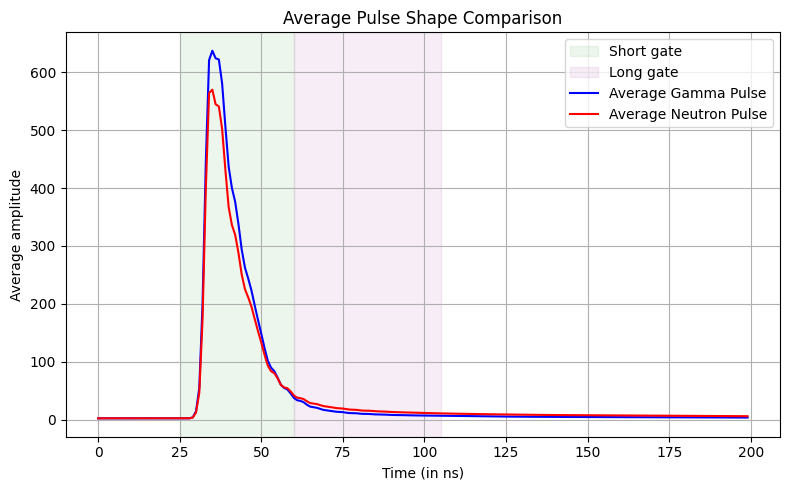

In [50]:
import matplotlib.pyplot as plt
import numpy as np

mean_waveform_gamma   = df_expanded_gamma.mean(axis=0).iloc[:-1]
mean_waveform_neutron = df_expanded_neutron.mean(axis=0).iloc[:-1]
x = np.arange(200)

short_start, split, long_end = 25, 60, 105

fig, ax = plt.subplots(figsize=(8, 5))

# Gate shading
ax.axvspan(short_start, split,    alpha=0.07, color='green',  label='Short gate')
ax.axvspan(split,       long_end, alpha=0.07, color='purple', label='Long gate')

ax.plot(x, mean_waveform_gamma[:200],   color='blue', linewidth=1.5, label='Average Gamma Pulse')
ax.plot(x, mean_waveform_neutron[:200], color='red',  linewidth=1.5, label='Average Neutron Pulse')


ax.set_xlabel("Time (in ns)")
ax.set_ylabel("Average amplitude")
ax.set_title("Average Pulse Shape Comparison")
ax.grid(True)

ax.legend()
for spine in ax.spines.values():
    spine.set_visible(True)

plt.tight_layout()
plt.show()

Charge Comparison Method (understanding the role of preprocessing on the logistic regression accuracy and FoM plots)

[Raw] Split=50 | FOM=0.4102 | Acc=0.9035 | AUC=0.9669
[Smoothed] Split=50 | FOM=0.4140 | Acc=0.9048 | AUC=0.9673
[Smoothed + Log] Split=50 | FOM=0.4913 | Acc=0.8896 | AUC=0.9518
[Raw] Split=55 | FOM=0.3807 | Acc=0.9279 | AUC=0.9811
[Smoothed] Split=55 | FOM=0.3736 | Acc=0.9282 | AUC=0.9814
[Smoothed + Log] Split=55 | FOM=0.5008 | Acc=0.8979 | AUC=0.9590
[Raw] Split=60 | FOM=0.3252 | Acc=0.9252 | AUC=0.9810
[Smoothed] Split=60 | FOM=0.3370 | Acc=0.9266 | AUC=0.9816
[Smoothed + Log] Split=60 | FOM=0.6111 | Acc=0.8978 | AUC=0.9591
[Raw] Split=65 | FOM=0.2819 | Acc=0.9153 | AUC=0.9776
[Smoothed] Split=65 | FOM=0.3233 | Acc=0.9158 | AUC=0.9781
[Smoothed + Log] Split=65 | FOM=0.5869 | Acc=0.8927 | AUC=0.9553


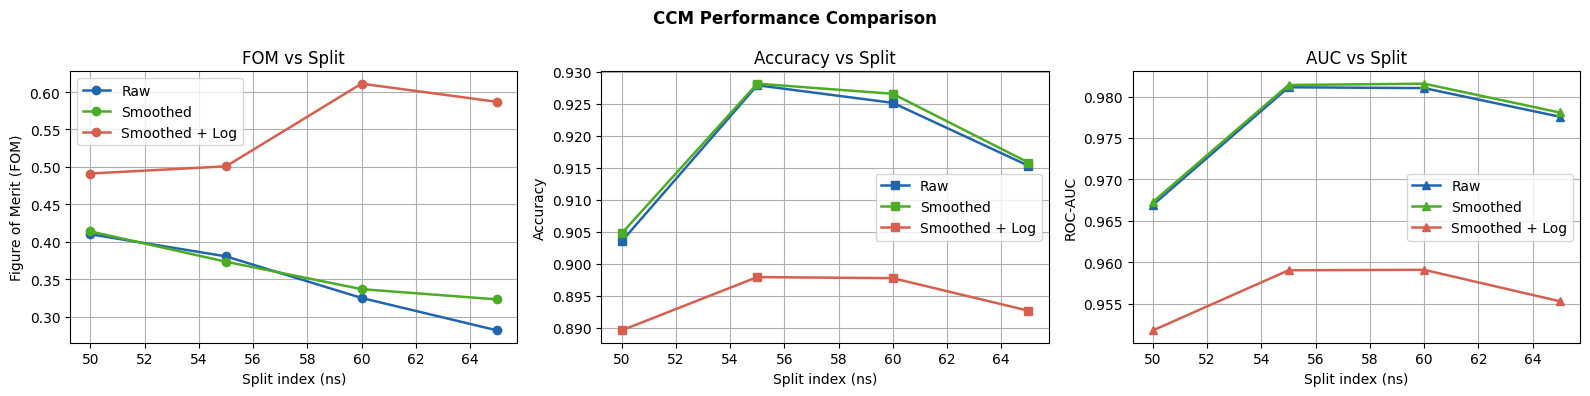

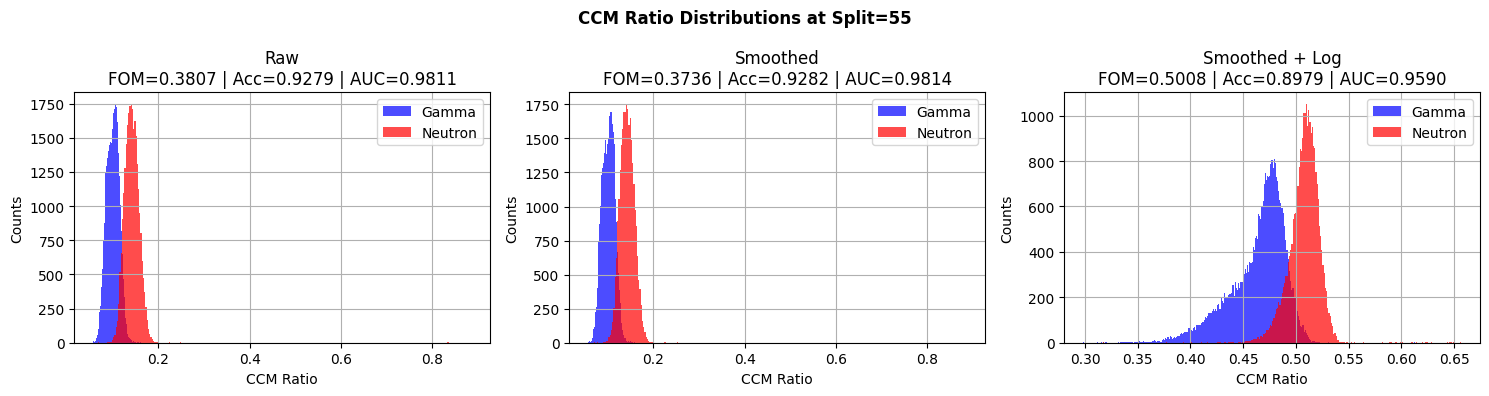

In [3]:
# CCM Performance Comparison: Raw vs Smoothed vs Smoothed+Log (Kuneh)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score

# ── Helper functions ──────────────────────────────────────────────────────────

def calculate_fom(gamma_data, neutron_data, bins=200):
    g_counts, g_edges = np.histogram(gamma_data, bins=bins)
    n_counts, n_edges = np.histogram(neutron_data, bins=bins)
    g_mids = (g_edges[:-1] + g_edges[1:]) / 2
    n_mids = (n_edges[:-1] + n_edges[1:]) / 2

    def get_fwhm(counts, mids):
        peak_idx  = np.argmax(counts)
        half_max  = counts[peak_idx] / 2
        left_idx  = np.where(counts[:peak_idx] <= half_max)[0]
        left_idx  = left_idx[-1] if len(left_idx) > 0 else 0
        right_idx = np.where(counts[peak_idx:] <= half_max)[0]
        right_idx = (right_idx[0] + peak_idx) if len(right_idx) > 0 else len(counts) - 1
        return mids[peak_idx], mids[right_idx] - mids[left_idx]

    g_peak, g_fwhm = get_fwhm(g_counts, g_mids)
    n_peak, n_fwhm = get_fwhm(n_counts, n_mids)
    return abs(n_peak - g_peak) / (g_fwhm + n_fwhm)


def get_accuracy(gamma_ratio, neutron_ratio):
    X = np.concatenate([gamma_ratio, neutron_ratio]).reshape(-1, 1)
    y = np.concatenate([np.zeros(len(gamma_ratio)), np.ones(len(neutron_ratio))])
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=42
    )
    clf = LogisticRegression()
    clf.fit(X_train, y_train)
    return accuracy_score(y_test, clf.predict(X_test))


def get_auc(gamma_ratio, neutron_ratio):
    X = np.concatenate([gamma_ratio, neutron_ratio])
    y = np.concatenate([np.zeros(len(gamma_ratio)), np.ones(len(neutron_ratio))])
    return roc_auc_score(y, X)


def moving_average(df, window=5):
    """Apply moving average smoothing row-wise."""
    return df.T.rolling(window=window, center=True, min_periods=1).mean().T


def compute_ratio_raw(df, split_local):
    """CCM on raw pulse."""
    short = df.iloc[:, :split_local].sum(axis=1)
    long_ = df.iloc[:, split_local:].sum(axis=1)
    return (long_ / (long_ + short)).abs()


def compute_ratio_smoothed(df, split_local, window=5):
    """CCM on smoothed pulse."""
    df_smooth = moving_average(df, window)
    short = df_smooth.iloc[:, :split_local].sum(axis=1)
    long_ = df_smooth.iloc[:, split_local:].sum(axis=1)
    return (long_ / (long_ + short)).abs()


def compute_ratio_smoothed_log(df, split_local, window=5, eps=1e-10):
    """CCM on log of smoothed pulse, clipping negatives."""
    df_smooth = moving_average(df, window)
    df_smooth = df_smooth.clip(lower=eps)
    df_log    = np.log(df_smooth)
    df_log    = df_log.clip(lower=0)
    short = df_log.iloc[:, :split_local].sum(axis=1)
    long_ = df_log.iloc[:, split_local:].sum(axis=1)
    return (long_ / (long_ + short)).abs()


# ── Parameters ────────────────────────────────────────────────────────────────

short_start = 25
long_end    = 105
splits      = [50, 55, 60, 65]
methods     = ['Raw', 'Smoothed', 'Smoothed + Log']
colors      = {'Raw': '#2166AC', 'Smoothed': '#4DAC26', 'Smoothed + Log': '#D6604D'}

# Pre-slice dataframes to the gate window
df_gamma   = df_expanded_gamma.iloc[:, short_start:long_end].copy()
df_neutron = df_expanded_neutron.iloc[:, short_start:long_end].copy()

# ── Collect results ───────────────────────────────────────────────────────────

results = {m: {'fom': [], 'acc': [], 'auc': [], 'g_ratio': [], 'n_ratio': []} for m in methods}

for split in splits:
    split_local = split - short_start

    for method in methods:
        if method == 'Raw':
            g_ratio = compute_ratio_raw(df_gamma,   split_local)
            n_ratio = compute_ratio_raw(df_neutron, split_local)
        elif method == 'Smoothed':
            g_ratio = compute_ratio_smoothed(df_gamma,   split_local)
            n_ratio = compute_ratio_smoothed(df_neutron, split_local)
        else:
            g_ratio = compute_ratio_smoothed_log(df_gamma,   split_local)
            n_ratio = compute_ratio_smoothed_log(df_neutron, split_local)

        fom = calculate_fom(g_ratio, n_ratio)
        acc = get_accuracy(g_ratio, n_ratio)
        auc = get_auc(g_ratio, n_ratio)

        results[method]['fom'].append(fom)
        results[method]['acc'].append(acc)
        results[method]['auc'].append(auc)
        results[method]['g_ratio'].append(g_ratio)
        results[method]['n_ratio'].append(n_ratio)

        print(f"[{method}] Split={split} | FOM={fom:.4f} | Acc={acc:.4f} | AUC={auc:.4f}")

# ── Plot 1: FOM, Accuracy, AUC vs split ──────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for method in methods:
    axes[0].plot(splits, results[method]['fom'], marker='o',
                 label=method, color=colors[method], linewidth=1.8)
axes[0].set_xlabel("Split index (ns)")
axes[0].set_ylabel("Figure of Merit (FOM)")
axes[0].set_title("FOM vs Split")
axes[0].legend()
axes[0].grid(True)
for spine in axes[0].spines.values():
    spine.set_visible(True)

for method in methods:
    axes[1].plot(splits, results[method]['acc'], marker='s',
                 label=method, color=colors[method], linewidth=1.8)
axes[1].set_xlabel("Split index (ns)")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Accuracy vs Split")
axes[1].legend()
axes[1].grid(True)
for spine in axes[1].spines.values():
    spine.set_visible(True)

for method in methods:
    axes[2].plot(splits, results[method]['auc'], marker='^',
                 label=method, color=colors[method], linewidth=1.8)
axes[2].set_xlabel("Split index (ns)")
axes[2].set_ylabel("ROC-AUC")
axes[2].set_title("AUC vs Split")
axes[2].legend()
axes[2].grid(True)
for spine in axes[2].spines.values():
    spine.set_visible(True)

plt.suptitle("CCM Performance Comparison", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig("fom_accuracy_auc_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

# ── Plot 2: Ratio histograms for best split (55) per method ──────────────────

best_split_idx = splits.index(55)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, method in enumerate(methods):
    g = results[method]['g_ratio'][best_split_idx]
    n = results[method]['n_ratio'][best_split_idx]
    axes[i].hist(g, bins=300, alpha=0.7, color='blue', label='Gamma')
    axes[i].hist(n, bins=300, alpha=0.7, color='red',  label='Neutron')
    axes[i].set_title(f"{method}\nFOM={results[method]['fom'][best_split_idx]:.4f} | "
                      f"Acc={results[method]['acc'][best_split_idx]:.4f} | "
                      f"AUC={results[method]['auc'][best_split_idx]:.4f}")
    axes[i].set_xlabel("CCM Ratio")
    axes[i].set_ylabel("Counts")
    axes[i].legend()
    axes[i].grid(True)
    for spine in axes[i].spines.values():
        spine.set_visible(True)

plt.suptitle("CCM Ratio Distributions at Split=55", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

CCM (PLotting the role of preprocessing)

[Raw] Split=50 | Acc=0.9035 | AUC=0.9661
[Smoothed] Split=50 | Acc=0.7989 | AUC=0.9431
[Smoothed → Log] Split=50 | Acc=0.5649 | AUC=0.8001
[Raw] Split=55 | Acc=0.9279 | AUC=0.9811
[Smoothed] Split=55 | Acc=0.8065 | AUC=0.9360
[Smoothed → Log] Split=55 | Acc=0.5651 | AUC=0.8060
[Raw] Split=60 | Acc=0.9252 | AUC=0.9813
[Smoothed] Split=60 | Acc=0.8049 | AUC=0.9278
[Smoothed → Log] Split=60 | Acc=0.5687 | AUC=0.8114
[Raw] Split=65 | Acc=0.9153 | AUC=0.9774
[Smoothed] Split=65 | Acc=0.8038 | AUC=0.9196
[Smoothed → Log] Split=65 | Acc=0.5772 | AUC=0.8157

Best: Raw @ split=55 | Acc=0.9279


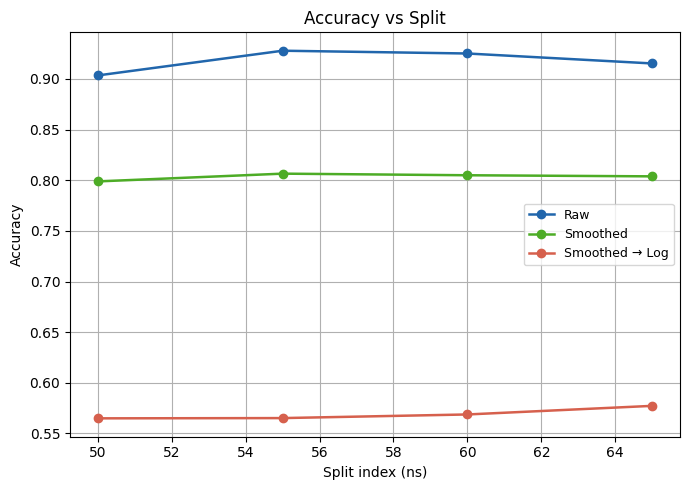

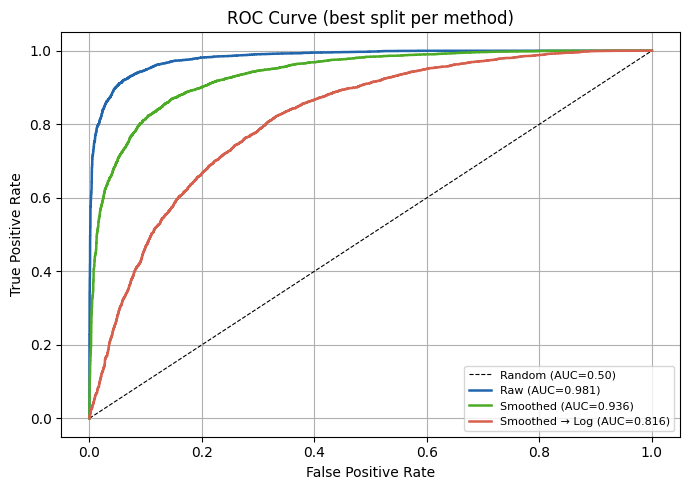

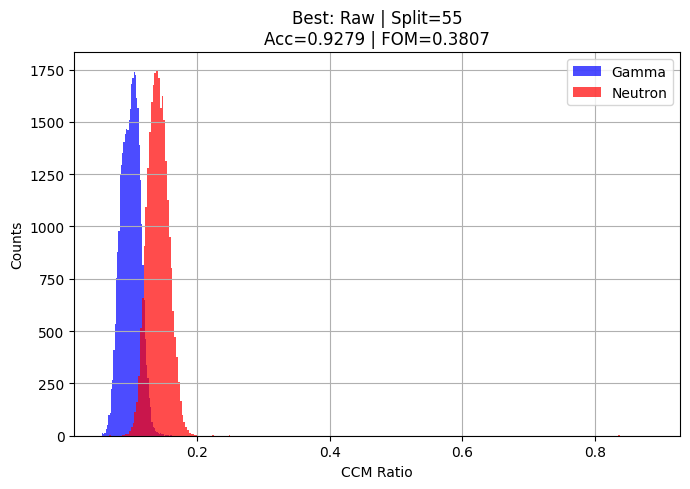

In [ ]:
# Final CCM Analysis Plot (Kuneh)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve

# ── Helper functions ──────────────────────────────────────────────────────────

def calculate_fom(gamma_data, neutron_data, bins=200):
    g_counts, g_edges = np.histogram(gamma_data, bins=bins)
    n_counts, n_edges = np.histogram(neutron_data, bins=bins)
    g_mids = (g_edges[:-1] + g_edges[1:]) / 2
    n_mids = (n_edges[:-1] + n_edges[1:]) / 2

    def get_fwhm(counts, mids):
        peak_idx  = np.argmax(counts)
        half_max  = counts[peak_idx] / 2
        left_idx  = np.where(counts[:peak_idx] <= half_max)[0]
        left_idx  = left_idx[-1] if len(left_idx) > 0 else 0
        right_idx = np.where(counts[peak_idx:] <= half_max)[0]
        right_idx = (right_idx[0] + peak_idx) if len(right_idx) > 0 else len(counts) - 1
        return mids[peak_idx], mids[right_idx] - mids[left_idx]

    g_peak, g_fwhm = get_fwhm(g_counts, g_mids)
    n_peak, n_fwhm = get_fwhm(n_counts, n_mids)
    return abs(n_peak - g_peak) / (g_fwhm + n_fwhm)


def get_accuracy_and_roc(gamma_ratio, neutron_ratio):
    X = np.concatenate([gamma_ratio, neutron_ratio]).reshape(-1, 1)
    y = np.concatenate([np.zeros(len(gamma_ratio)), np.ones(len(neutron_ratio))])

    mask = np.isfinite(X.ravel())
    X, y = X[mask], y[mask]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=42
    )
    clf = LogisticRegression()
    clf.fit(X_train, y_train)
    y_pred      = clf.predict(X_test)
    y_prob      = clf.predict_proba(X_test)[:, 1]
    acc         = accuracy_score(y_test, y_pred)
    auc         = roc_auc_score(y_test, y_prob)
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    return acc, auc, fpr, tpr


def moving_average(df, window=5):
    return df.T.rolling(window=window, center=True, min_periods=1).mean().T


def compute_ratio_raw(df, split_local):
    short = df.iloc[:, :split_local].sum(axis=1)
    long_ = df.iloc[:, split_local:].sum(axis=1)
    return (long_ / (long_ + short)).abs()


def compute_ratio_smoothed(df, split_local, window=5):
    df_s  = moving_average(df, window)
    short = df_s.iloc[:, :split_local].sum(axis=1)
    long_ = df_s.iloc[:, split_local:].sum(axis=1)
    return (long_ / (long_ + short)).abs()


def compute_ratio_smoothed_log(df, split_local, window=5, eps=1e-10):
    df_s   = moving_average(df, window)
    df_s   = df_s.clip(lower=eps)
    df_log = np.log(df_s)
    df_log = df_log.clip(lower=0)
    short  = df_log.iloc[:, :split_local].sum(axis=1)
    long_  = df_log.iloc[:, split_local:].sum(axis=1)
    total  = long_ + short
    ratio  = (long_ / total.replace(0, np.nan)).abs()
    return ratio.fillna(0)


# ── Parameters ────────────────────────────────────────────────────────────────

short_start = 25
long_end    = 105
splits      = [50, 55, 60, 65]
methods     = ['Raw', 'Smoothed', 'Smoothed → Log']
colors      = {
    'Raw':            '#2166AC',
    'Smoothed':       '#4DAC26',
    'Smoothed → Log': '#D6604D'
}

df_gamma   = df_expanded_gamma.iloc[:, short_start:long_end].copy()
df_neutron = df_expanded_neutron.iloc[:, short_start:long_end].copy()

# ── Collect results ───────────────────────────────────────────────────────────

results = {m: {'acc': [], 'auc': [], 'fpr': [], 'tpr': [],
               'g_ratio': [], 'n_ratio': []} for m in methods}

for split in splits:
    split_local = split - short_start

    for method in methods:
        if method == 'Raw':
            g_ratio = compute_ratio_raw(df_gamma,   split_local)
            n_ratio = compute_ratio_raw(df_neutron, split_local)
        elif method == 'Smoothed':
            g_ratio = compute_ratio_smoothed(df_gamma,   split_local)
            n_ratio = compute_ratio_smoothed(df_neutron, split_local)
        else:
            g_ratio = compute_ratio_smoothed_log(df_gamma,   split_local)
            n_ratio = compute_ratio_smoothed_log(df_neutron, split_local)

        acc, auc, fpr, tpr = get_accuracy_and_roc(g_ratio, n_ratio)

        results[method]['acc'].append(acc)
        results[method]['auc'].append(auc)
        results[method]['fpr'].append(fpr)
        results[method]['tpr'].append(tpr)
        results[method]['g_ratio'].append(g_ratio)
        results[method]['n_ratio'].append(n_ratio)

        print(f"[{method}] Split={split} | Acc={acc:.4f} | AUC={auc:.4f}")

# ── Find best method + split by accuracy ─────────────────────────────────────

best_acc       = 0
best_method    = None
best_split_idx = 0

for method in methods:
    for si, acc in enumerate(results[method]['acc']):
        if acc > best_acc:
            best_acc       = acc
            best_method    = method
            best_split_idx = si

best_split = splits[best_split_idx]
print(f"\nBest: {best_method} @ split={best_split} | Acc={best_acc:.4f}")

def best_split_for(method):
    return int(np.argmax(results[method]['acc']))

# ── Plot 1: Accuracy vs Split ─────────────────────────────────────────────────

fig1, ax1 = plt.subplots(figsize=(7, 5))
for method in methods:
    ax1.plot(splits, results[method]['acc'], marker='o',
             label=method, color=colors[method], linewidth=1.8)
ax1.set_xlabel("Split index (ns)")
ax1.set_ylabel("Accuracy")
ax1.set_title("Accuracy vs Split")
ax1.legend(fontsize=9)
ax1.grid(True)
for spine in ax1.spines.values():
    spine.set_visible(True)
plt.tight_layout()
plt.savefig("plot1_accuracy_vs_split.png", dpi=150, bbox_inches='tight')
plt.show()

# ── Plot 2: ROC curves ────────────────────────────────────────────────────────

fig2, ax2 = plt.subplots(figsize=(7, 5))
ax2.plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='Random (AUC=0.50)')
for method in methods:
    si  = best_split_for(method)
    fpr = results[method]['fpr'][si]
    tpr = results[method]['tpr'][si]
    auc = results[method]['auc'][si]
    ax2.plot(fpr, tpr, color=colors[method], linewidth=1.8,
             label=f"{method} (AUC={auc:.3f})")
ax2.set_xlabel("False Positive Rate")
ax2.set_ylabel("True Positive Rate")
ax2.set_title("ROC Curve (best split per method)")
ax2.legend(fontsize=8)
ax2.grid(True)
for spine in ax2.spines.values():
    spine.set_visible(True)
plt.tight_layout()
plt.savefig("plot2_roc_curves.png", dpi=150, bbox_inches='tight')
plt.show()

# ── Plot 3: Histogram for best method + split ─────────────────────────────────

g_best = results[best_method]['g_ratio'][best_split_idx]
n_best = results[best_method]['n_ratio'][best_split_idx]
fom    = calculate_fom(g_best, n_best)

fig3, ax3 = plt.subplots(figsize=(7, 5))
ax3.hist(g_best, bins=300, alpha=0.7, color='blue', label='Gamma')
ax3.hist(n_best, bins=300, alpha=0.7, color='red',  label='Neutron')
ax3.set_xlabel("CCM Ratio")
ax3.set_ylabel("Counts")
ax3.set_title(f"Best: {best_method} | Split={best_split}\n"
              f"Acc={best_acc:.4f} | FOM={fom:.4f}")
ax3.legend()
ax3.grid(True)
for spine in ax3.spines.values():
    spine.set_visible(True)
plt.tight_layout()
plt.show()

Pile up cases


Continuing from existing clean dataframes — Gamma: 33864 | Neutron: 26118



Gamma   — pile-up found: 1 / 33864 (0.00%)
Neutron — pile-up found: 1 / 26118 (0.00%)


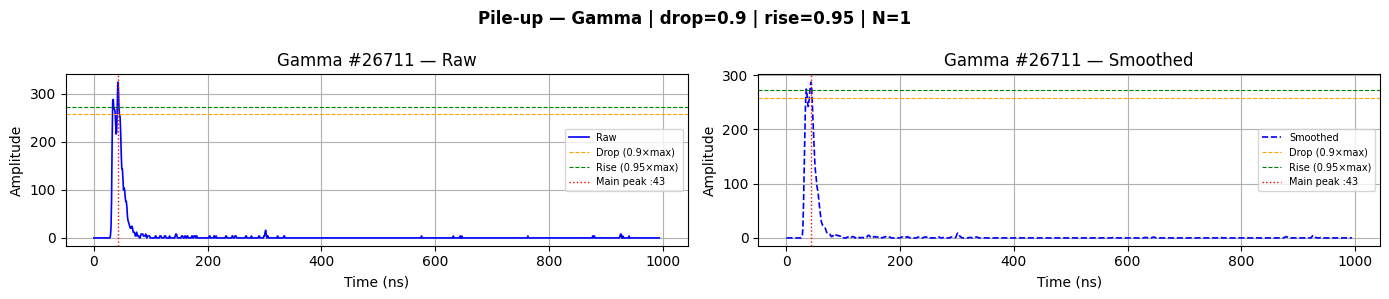

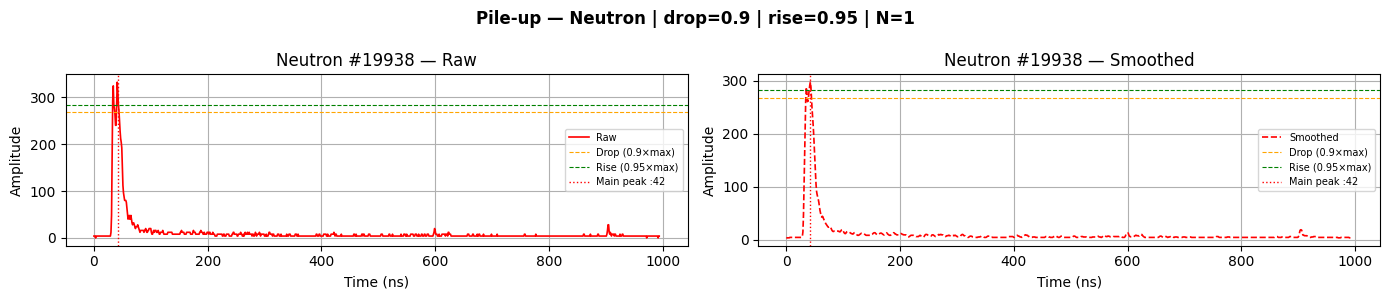

Not removed. Clean dataframes unchanged.


In [15]:
from scipy.signal import find_peaks

def detect_pileup(df_smooth, drop_threshold=0.1, rise_threshold=0.3):
    pileup_indices = []
    
    for idx in range(len(df_smooth)):
        waveform       = df_smooth.iloc[idx, :].values.astype(float)
        max_amp        = waveform.max()
        first_peak_idx = np.argmax(waveform)

        #── Check AFTER the main peak ──────────────────────────────────────
        tail    = waveform[first_peak_idx:]
        dropped = np.where(tail < drop_threshold * max_amp)[0]
        if len(dropped) > 0:
            first_drop_idx = dropped[0]
            post_drop      = tail[first_drop_idx:]
            if np.any(post_drop > rise_threshold * max_amp):
                pileup_indices.append(idx)
                continue

        # ── Check BEFORE the main peak ────────────────────────────────────
        pre_peak = waveform[:first_peak_idx]
        if len(pre_peak) == 0:
            continue
        dropped_pre = np.where(pre_peak < drop_threshold * max_amp)[0]
        if len(dropped_pre) == 0:
            continue
        last_drop_idx = dropped_pre[-1]
        pre_drop      = pre_peak[:last_drop_idx]
        if np.any(pre_drop > rise_threshold * max_amp):
            pileup_indices.append(idx)

    return pileup_indices


def _plot_pileup(df_raw, df_smooth, pileup_indices, label, color,
                 drop_threshold, rise_threshold, n_samples):
    if len(pileup_indices) == 0:
        print(f"No pile-up detected for {label}")
        return

    sample_indices = np.random.choice(pileup_indices,
                                       min(n_samples, len(pileup_indices)),
                                       replace=False)
    fig, axes = plt.subplots(len(sample_indices), 2,
                              figsize=(14, len(sample_indices) * 3))
    if len(sample_indices) == 1:
        axes = np.expand_dims(axes, axis=0)

    for i, idx in enumerate(sample_indices):
        raw      = df_raw.iloc[idx, :995].values.astype(float)
        smoothed = df_smooth.iloc[idx, :995].values.astype(float)
        max_amp  = smoothed.max()
        first_peak_idx = np.argmax(smoothed)
        for col, data, title_suffix in zip(
            [0, 1], [raw, smoothed], ['Raw', 'Smoothed']
        ):
            axes[i, col].plot(data, color=color, linewidth=1.2,
                               linestyle='-' if col == 0 else '--',
                               label=title_suffix)
            axes[i, col].axhline(drop_threshold * max_amp, color='orange',
                                  linewidth=0.8, linestyle='--',
                                  label=f'Drop ({drop_threshold}×max)')
            axes[i, col].axhline(rise_threshold * max_amp, color='green',
                                  linewidth=0.8, linestyle='--',
                                  label=f'Rise ({rise_threshold}×max)')
            axes[i, col].axvline(np.argmax(smoothed), color='red',
                                  linewidth=1.0, linestyle=':', label=f'Main peak :{first_peak_idx}')
            axes[i, col].set_title(f"{label} #{idx} — {title_suffix}")
            axes[i, col].set_xlabel("Time (ns)")
            axes[i, col].set_ylabel("Amplitude")
            axes[i, col].legend(fontsize=7)
            axes[i, col].grid(True)
            for spine in axes[i, col].spines.values():
                spine.set_visible(True)

    plt.suptitle(f"Pile-up — {label} | drop={drop_threshold} | "
                 f"rise={rise_threshold} | N={len(pileup_indices)}",
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    
    plt.show()


def iterative_pileup_removal(window=5):
    global df_clean_gamma, df_clean_neutron

    # ── Initialise clean dataframes if not already existing ───────────────
    try:
        df_clean_gamma
        print(f"Continuing from existing clean dataframes — "
              f"Gamma: {len(df_clean_gamma)} | Neutron: {len(df_clean_neutron)}")
    except NameError:
        df_clean_gamma   = df_expanded_gamma.copy()
        df_clean_neutron = df_expanded_neutron.copy()
        print(f"Initialising clean dataframes — "
              f"Gamma: {len(df_clean_gamma)} | Neutron: {len(df_clean_neutron)}")

    drop_threshold = float(input("Enter drop threshold (e.g. 0.1): "))
    rise_threshold = float(input("Enter rise threshold (e.g. 0.3): "))
    n_samples      = int(input("Number of sample pulses to plot (e.g. 6): "))

    # ── Smooth current clean dataframes ───────────────────────────────────
    df_smooth_clean_gamma   = moving_average(df_clean_gamma,   window=window)
    df_smooth_clean_neutron = moving_average(df_clean_neutron, window=window)

    # ── Detect pile-up ─────────────────────────────────────────────────────
    pileup_gamma   = detect_pileup(df_smooth_clean_gamma,   drop_threshold, rise_threshold)
    pileup_neutron = detect_pileup(df_smooth_clean_neutron, drop_threshold, rise_threshold)

    print(f"\nGamma   — pile-up found: {len(pileup_gamma)} / {len(df_clean_gamma)} "
          f"({100*len(pileup_gamma)/len(df_clean_gamma):.2f}%)")
    print(f"Neutron — pile-up found: {len(pileup_neutron)} / {len(df_clean_neutron)} "
          f"({100*len(pileup_neutron)/len(df_clean_neutron):.2f}%)")

    # ── Plot samples ───────────────────────────────────────────────────────
    _plot_pileup(df_clean_gamma,   df_smooth_clean_gamma,
                 pileup_gamma,   'Gamma',   'blue',
                 drop_threshold, rise_threshold, n_samples)
    _plot_pileup(df_clean_neutron, df_smooth_clean_neutron,
                 pileup_neutron, 'Neutron', 'red',
                 drop_threshold, rise_threshold, n_samples)

    confirm = input("\nRemove these pile-up pulses from clean dataframes? (yes/no): ").strip().lower()

    if confirm == 'yes':
        df_clean_gamma = (df_clean_gamma
                          .drop(index=df_clean_gamma.index[pileup_gamma])
                          .reset_index(drop=True))
        df_clean_neutron = (df_clean_neutron
                            .drop(index=df_clean_neutron.index[pileup_neutron])
                            .reset_index(drop=True))
        print(f"\nRemoved successfully.")
        print(f"Clean dataframes now  — Gamma: {len(df_clean_gamma)} | "
              f"Neutron: {len(df_clean_neutron)}")
        print(f"Total removed so far  — Gamma: {len(df_expanded_gamma) - len(df_clean_gamma)} | "
              f"Neutron: {len(df_expanded_neutron) - len(df_clean_neutron)}")
    else:
        print("Not removed. Clean dataframes unchanged.")


# ── Run iterative removal — rerun this cell with different thresholds ─────────
iterative_pileup_removal(window=5)


Late peaks removal

Continuing from existing clean dataframes — Gamma: 33864 | Neutron: 26118

Gamma   — late peak (argmax > 45): 1 / 33864 (0.00%)
Neutron — late peak (argmax > 45): 7 / 26118 (0.03%)


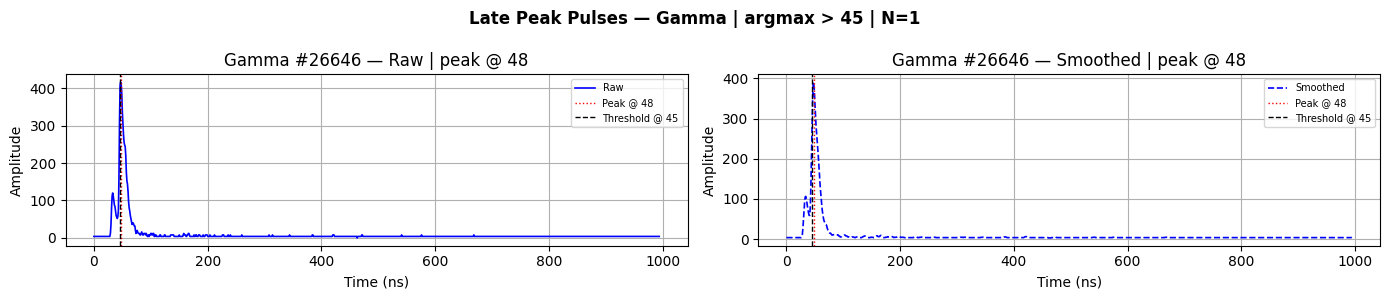

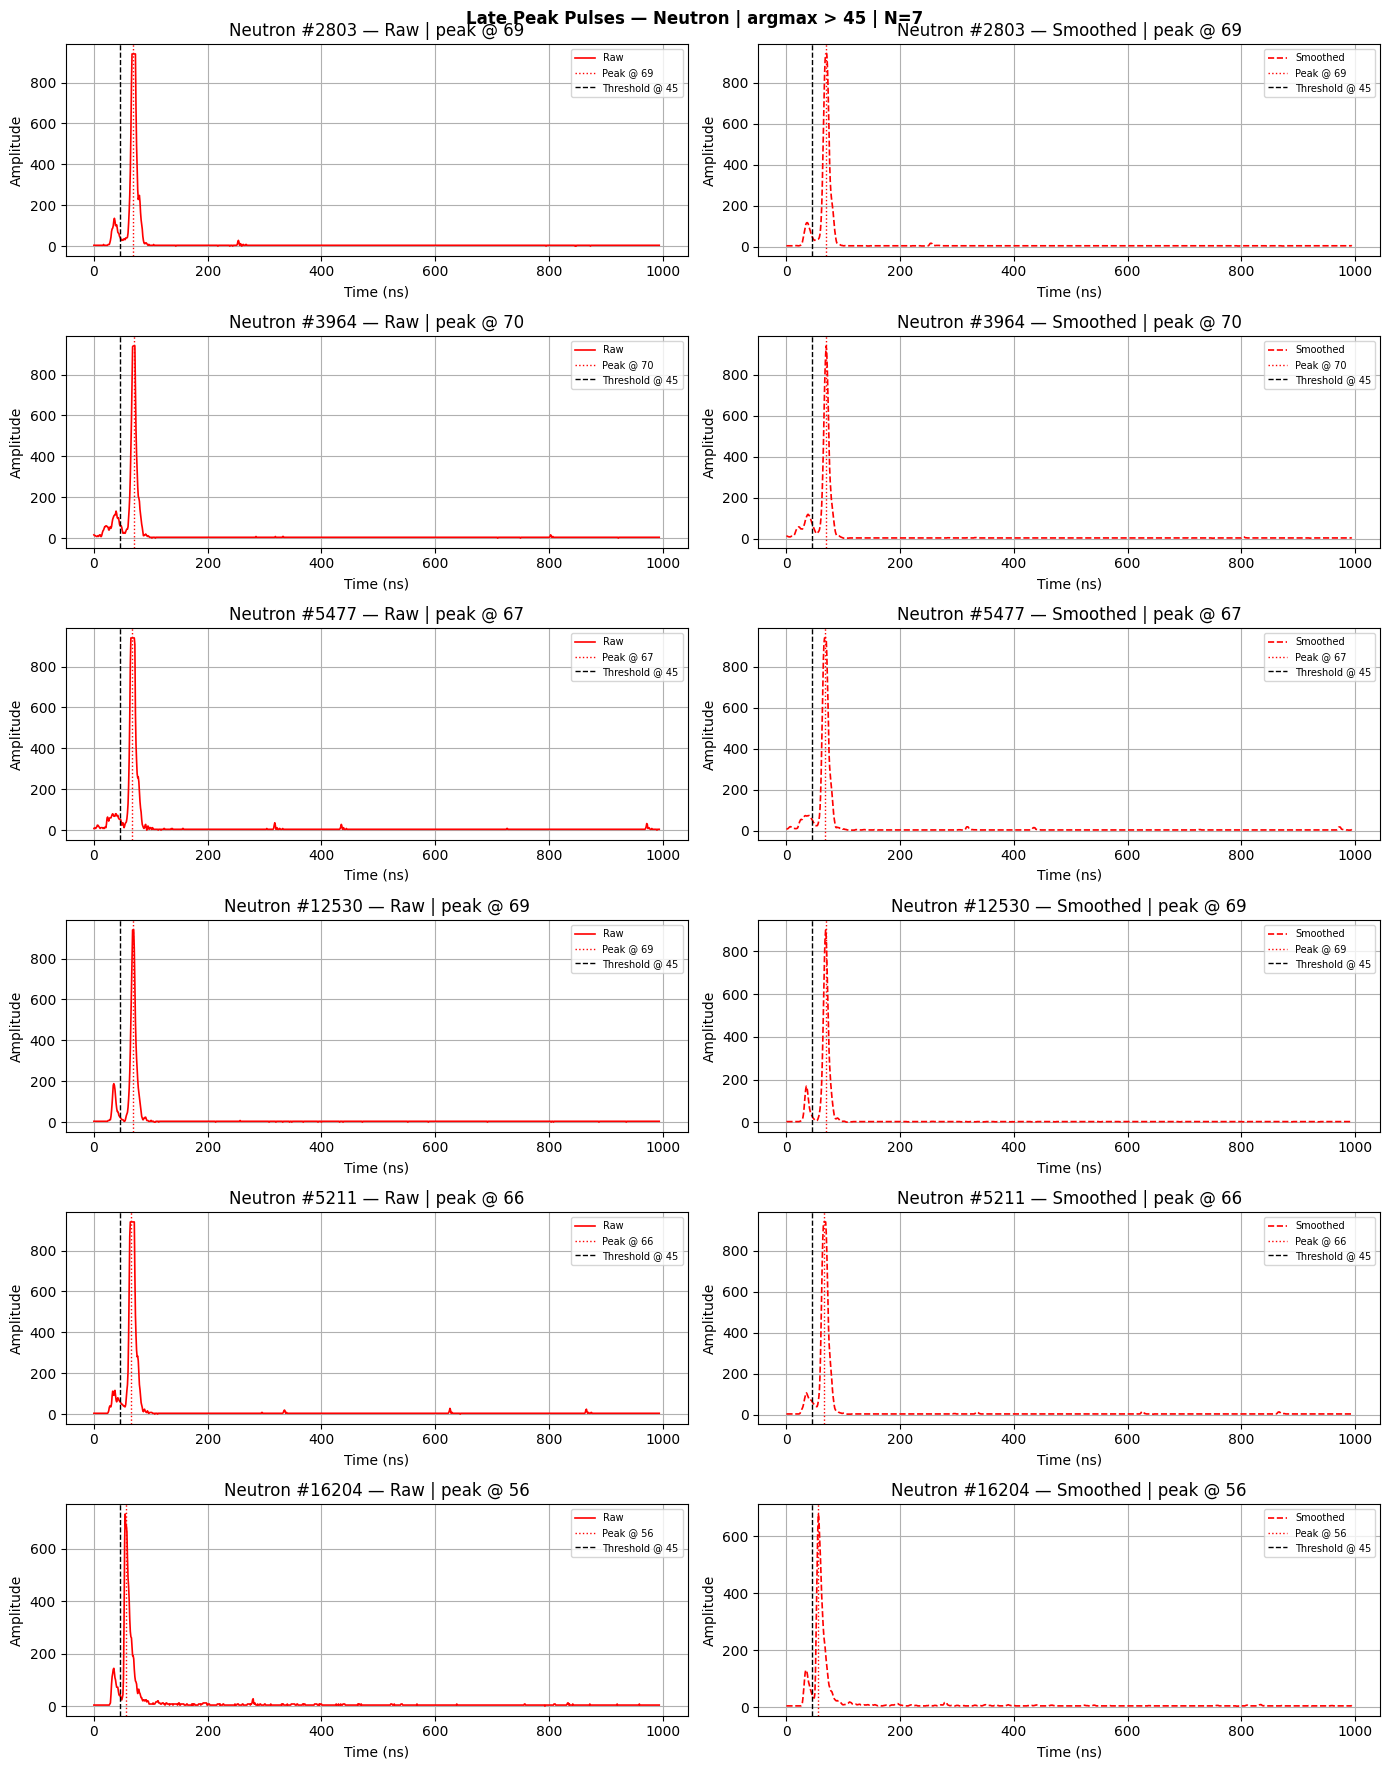


Removed successfully.
Clean dataframes now  — Gamma: 33863 | Neutron: 26111
Total removed so far  — Gamma: 5 | Neutron: 25


In [16]:
def detect_and_remove_late_peak(threshold_idx=40, n_samples=6, window=5):
    """
    Detects pulses whose peak (argmax) occurs after threshold_idx.
    Plots samples, then asks if you want to remove them from clean dataframes.
    """
    global df_clean_gamma, df_clean_neutron

    # ── Initialise clean dataframes if not already existing ───────────────
    try:
        df_clean_gamma
        print(f"Continuing from existing clean dataframes — "
              f"Gamma: {len(df_clean_gamma)} | Neutron: {len(df_clean_neutron)}")
    except NameError:
        df_clean_gamma   = df_expanded_gamma.copy()
        df_clean_neutron = df_expanded_neutron.copy()
        print(f"Initialising clean dataframes — "
              f"Gamma: {len(df_clean_gamma)} | Neutron: {len(df_clean_neutron)}")

    # ── Smooth current clean dataframes ───────────────────────────────────
    df_smooth_clean_gamma   = moving_average(df_clean_gamma,   window=window)
    df_smooth_clean_neutron = moving_average(df_clean_neutron, window=window)

    # ── Detect late peak pulses ────────────────────────────────────────────
    def find_late_peaks(df_smooth):
        late_indices = []
        for idx in range(len(df_smooth)):
            waveform       = df_smooth.iloc[idx, :].values.astype(float)
            first_peak_idx = np.argmax(waveform)
            if first_peak_idx > threshold_idx:
                late_indices.append(idx)
        return late_indices

    late_gamma   = find_late_peaks(df_smooth_clean_gamma)
    late_neutron = find_late_peaks(df_smooth_clean_neutron)

    print(f"\nGamma   — late peak (argmax > {threshold_idx}): "
          f"{len(late_gamma)} / {len(df_clean_gamma)} "
          f"({100*len(late_gamma)/len(df_clean_gamma):.2f}%)")
    print(f"Neutron — late peak (argmax > {threshold_idx}): "
          f"{len(late_neutron)} / {len(df_clean_neutron)} "
          f"({100*len(late_neutron)/len(df_clean_neutron):.2f}%)")

    # ── Plot helper ───────────────────────────────────────────────────────
    def plot_late_peaks(df_raw, df_smooth, late_indices, label, color):
        if len(late_indices) == 0:
            print(f"No late peak pulses detected for {label}")
            return

        sample_indices = np.random.choice(late_indices,
                                           min(n_samples, len(late_indices)),
                                           replace=False)
        fig, axes = plt.subplots(len(sample_indices), 2,
                                  figsize=(14, len(sample_indices) * 3))
        if len(sample_indices) == 1:
            axes = np.expand_dims(axes, axis=0)

        for i, idx in enumerate(sample_indices):
            raw            = df_raw.iloc[idx, :995].values.astype(float)
            smoothed       = df_smooth.iloc[idx, :995].values.astype(float)
            peak_idx       = np.argmax(smoothed)

            for col, data, title_suffix in zip(
                [0, 1], [raw, smoothed], ['Raw', 'Smoothed']
            ):
                axes[i, col].plot(data, color=color, linewidth=1.2,
                                   linestyle='-' if col == 0 else '--',
                                   label=title_suffix)
                axes[i, col].axvline(peak_idx, color='red', linewidth=1.0,
                                      linestyle=':', label=f'Peak @ {peak_idx}')
                axes[i, col].axvline(threshold_idx, color='black', linewidth=1.0,
                                      linestyle='--', label=f'Threshold @ {threshold_idx}')
                axes[i, col].set_title(f"{label} #{idx} — {title_suffix} | peak @ {peak_idx}")
                axes[i, col].set_xlabel("Time (ns)")
                axes[i, col].set_ylabel("Amplitude")
                axes[i, col].legend(fontsize=7)
                axes[i, col].grid(True)
                for spine in axes[i, col].spines.values():
                    spine.set_visible(True)

        plt.suptitle(f"Late Peak Pulses — {label} | argmax > {threshold_idx} | "
                     f"N={len(late_indices)}",
                     fontsize=12, fontweight='bold')
        plt.tight_layout()
        plt.savefig(f"late_peak_{label.lower()}_threshold{threshold_idx}.png",
                    dpi=150, bbox_inches='tight')
        plt.show()

    # ── Plot ──────────────────────────────────────────────────────────────
    plot_late_peaks(df_clean_gamma,   df_smooth_clean_gamma,
                    late_gamma,   'Gamma',   'blue')
    plot_late_peaks(df_clean_neutron, df_smooth_clean_neutron,
                    late_neutron, 'Neutron', 'red')

    # ── Confirm removal ───────────────────────────────────────────────────
    confirm = input(f"\nRemove pulses with peak after index {threshold_idx} "
                    f"from clean dataframes? (yes/no): ").strip().lower()

    if confirm == 'yes':
        df_clean_gamma = (df_clean_gamma
                          .drop(index=df_clean_gamma.index[late_gamma])
                          .reset_index(drop=True))
        df_clean_neutron = (df_clean_neutron
                            .drop(index=df_clean_neutron.index[late_neutron])
                            .reset_index(drop=True))
        print(f"\nRemoved successfully.")
        print(f"Clean dataframes now  — Gamma: {len(df_clean_gamma)} | "
              f"Neutron: {len(df_clean_neutron)}")
        print(f"Total removed so far  — Gamma: {len(df_expanded_gamma) - len(df_clean_gamma)} | "
              f"Neutron: {len(df_expanded_neutron) - len(df_clean_neutron)}")
    else:
        print("Not removed. Clean dataframes unchanged.")


# ── Run — change threshold_idx and n_samples as needed ───────────────────────
detect_and_remove_late_peak(threshold_idx=45, n_samples=6, window=5)

In [ ]:
'''saving df_clean'''
df_clean_gamma.to_csv("Plastic Scintillator 1\df_clean_gamma.csv", index=False)
df_clean_neutron.to_csv("Plastic Scintillator 1\df_clean_neutron.csv", index=False)
print("Saved.")

'''To load df_clean'''
# df_clean_gamma   = pd.read_csv("df_clean_gamma.csv")
# df_clean_neutron = pd.read_csv("df_clean_neutron.csv")
# print(f"Loaded — Gamma: {len(df_clean_gamma)} | Neutron: {len(df_clean_neutron)}")

Saved.


── Original data ────────────────────────────────────────────────────────
Split=50 | Acc=0.9048 | AUC=0.9665
Split=55 | Acc=0.9282 | AUC=0.9813
Split=60 | Acc=0.9266 | AUC=0.9817
Split=65 | Acc=0.9158 | AUC=0.9779
── Clean data ───────────────────────────────────────────────────────────
Split=50 | Acc=0.9037 | AUC=0.9675
Split=55 | Acc=0.9288 | AUC=0.9824
Split=60 | Acc=0.9292 | AUC=0.9826
Split=65 | Acc=0.9218 | AUC=0.9789

Best split — Original: 55 (Acc=0.9282)
Best split — Clean:    60 (Acc=0.9292)


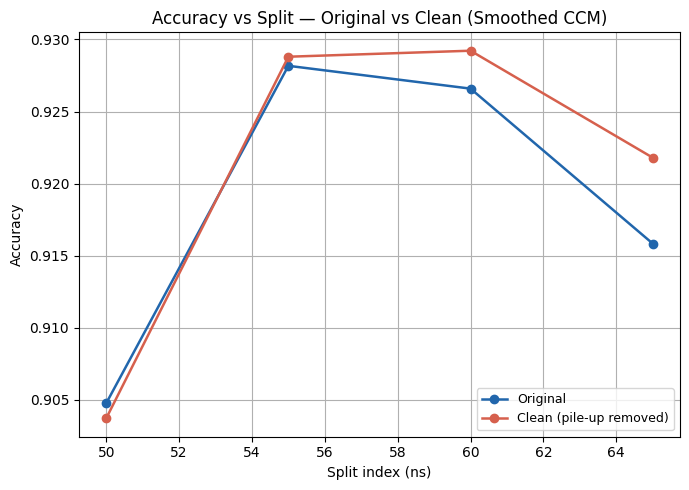

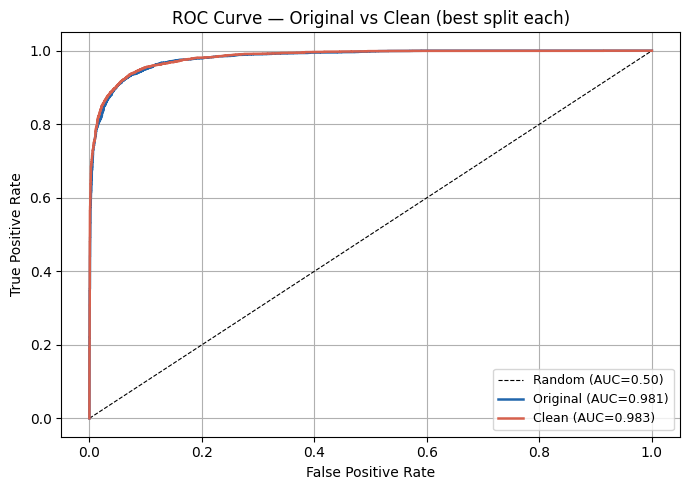

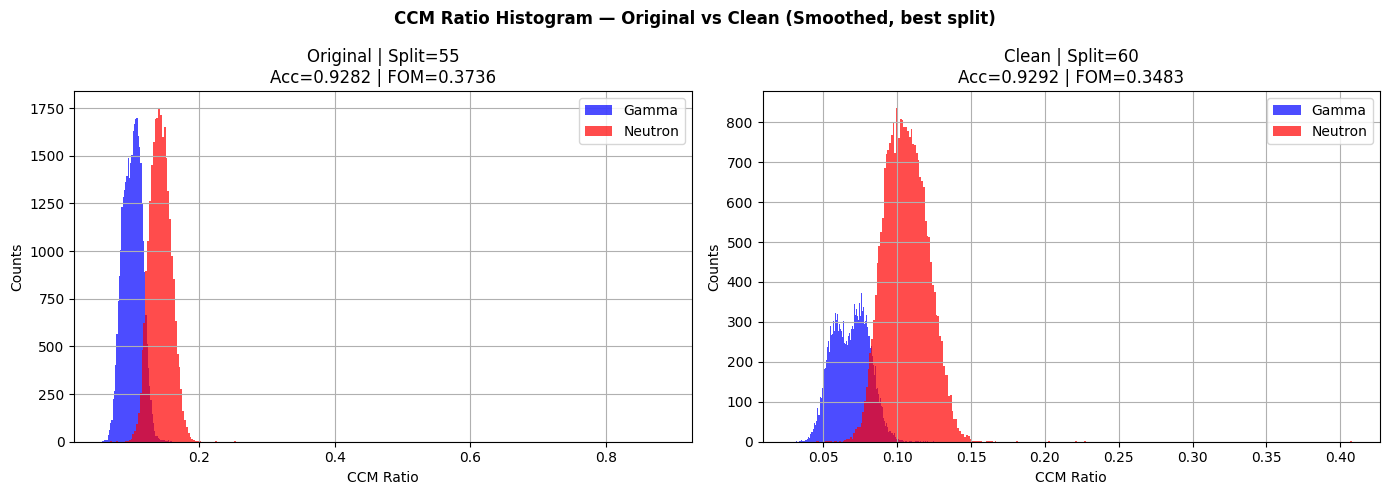

In [21]:
# ── Final Comparison: Original vs Clean Data (Kuneh) ─────────────────────────

short_start = 25
long_end    = 105
splits      = [50, 55, 60, 65]

colors = {
    'Original': '#2166AC',
    'Clean':    '#D6604D'
}

# ── Collect results for both datasets ────────────────────────────────────────

def run_ccm(df_g, df_n, splits, short_start, long_end):
    res = {'acc': [], 'auc': [], 'fpr': [], 'tpr': [], 'g_ratio': [], 'n_ratio': []}
    df_g_sliced = df_g.iloc[:, short_start:long_end].copy()
    df_n_sliced = df_n.iloc[:, short_start:long_end].copy()
    for split in splits:
        split_local = split - short_start
        g_ratio = compute_ratio_smoothed(df_g_sliced, split_local)
        n_ratio = compute_ratio_smoothed(df_n_sliced, split_local)
        acc, auc, fpr, tpr = get_accuracy_and_roc(g_ratio, n_ratio)
        res['acc'].append(acc)
        res['auc'].append(auc)
        res['fpr'].append(fpr)
        res['tpr'].append(tpr)
        res['g_ratio'].append(g_ratio)
        res['n_ratio'].append(n_ratio)
        print(f"Split={split} | Acc={acc:.4f} | AUC={auc:.4f}")
    return res

print("── Original data ────────────────────────────────────────────────────────")
res_original = run_ccm(df_expanded_gamma, df_expanded_neutron, splits, short_start, long_end)

print("── Clean data ───────────────────────────────────────────────────────────")
res_clean    = run_ccm(df_clean_gamma,    df_clean_neutron,    splits, short_start, long_end)

# ── Find best split per dataset ───────────────────────────────────────────────

best_split_orig_idx  = int(np.argmax(res_original['acc']))
best_split_clean_idx = int(np.argmax(res_clean['acc']))
best_split_orig      = splits[best_split_orig_idx]
best_split_clean     = splits[best_split_clean_idx]

print(f"\nBest split — Original: {best_split_orig} (Acc={res_original['acc'][best_split_orig_idx]:.4f})")
print(f"Best split — Clean:    {best_split_clean} (Acc={res_clean['acc'][best_split_clean_idx]:.4f})")

# ── Plot 1: Accuracy vs Split ─────────────────────────────────────────────────

fig1, ax1 = plt.subplots(figsize=(7, 5))
ax1.plot(splits, res_original['acc'], marker='o', linewidth=1.8,
         color=colors['Original'], label='Original')
ax1.plot(splits, res_clean['acc'],    marker='o', linewidth=1.8,
         color=colors['Clean'],    label='Clean (pile-up removed)')
ax1.set_xlabel("Split index (ns)")
ax1.set_ylabel("Accuracy")
ax1.set_title("Accuracy vs Split — Original vs Clean (Smoothed CCM)")
ax1.legend(fontsize=9)
ax1.grid(True)
for spine in ax1.spines.values():
    spine.set_visible(True)
plt.tight_layout()

plt.show()

# ── Plot 2: ROC curves ────────────────────────────────────────────────────────

fig2, ax2 = plt.subplots(figsize=(7, 5))
ax2.plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='Random (AUC=0.50)')

fpr_orig = res_original['fpr'][best_split_orig_idx]
tpr_orig = res_original['tpr'][best_split_orig_idx]
auc_orig = res_original['auc'][best_split_orig_idx]
ax2.plot(fpr_orig, tpr_orig, color=colors['Original'], linewidth=1.8,
         label=f"Original (AUC={auc_orig:.3f})")

fpr_clean = res_clean['fpr'][best_split_clean_idx]
tpr_clean = res_clean['tpr'][best_split_clean_idx]
auc_clean = res_clean['auc'][best_split_clean_idx]
ax2.plot(fpr_clean, tpr_clean, color=colors['Clean'], linewidth=1.8,
         label=f"Clean (AUC={auc_clean:.3f})")

ax2.set_xlabel("False Positive Rate")
ax2.set_ylabel("True Positive Rate")
ax2.set_title("ROC Curve — Original vs Clean (best split each)")
ax2.legend(fontsize=9)
ax2.grid(True)
for spine in ax2.spines.values():
    spine.set_visible(True)
plt.tight_layout()

plt.show()

# ── Plot 3: Histograms side by side ──────────────────────────────────────────

fig3, axes3 = plt.subplots(1, 2, figsize=(14, 5))

g_orig = res_original['g_ratio'][best_split_orig_idx]
n_orig = res_original['n_ratio'][best_split_orig_idx]
fom_orig = calculate_fom(g_orig, n_orig)

axes3[0].hist(g_orig, bins=300, alpha=0.7, color='blue', label='Gamma')
axes3[0].hist(n_orig, bins=300, alpha=0.7, color='red',  label='Neutron')
axes3[0].set_xlabel("CCM Ratio")
axes3[0].set_ylabel("Counts")
axes3[0].set_title(f"Original | Split={best_split_orig}\n"
                   f"Acc={res_original['acc'][best_split_orig_idx]:.4f} | FOM={fom_orig:.4f}")
axes3[0].legend()
axes3[0].grid(True)
for spine in axes3[0].spines.values():
    spine.set_visible(True)

g_clean = res_clean['g_ratio'][best_split_clean_idx]
n_clean = res_clean['n_ratio'][best_split_clean_idx]
fom_clean = calculate_fom(g_clean, n_clean)

axes3[1].hist(g_clean, bins=300, alpha=0.7, color='blue', label='Gamma')
axes3[1].hist(n_clean, bins=300, alpha=0.7, color='red',  label='Neutron')
axes3[1].set_xlabel("CCM Ratio")
axes3[1].set_ylabel("Counts")
axes3[1].set_title(f"Clean | Split={best_split_clean}\n"
                   f"Acc={res_clean['acc'][best_split_clean_idx]:.4f} | FOM={fom_clean:.4f}")
axes3[1].legend()
axes3[1].grid(True)
for spine in axes3[1].spines.values():
    spine.set_visible(True)

plt.suptitle("CCM Ratio Histogram — Original vs Clean (Smoothed, best split)",
             fontsize=12, fontweight='bold')
plt.tight_layout()

plt.show()

Histogram plotting for original vs cleaned at the same split

60004.0
59974.0


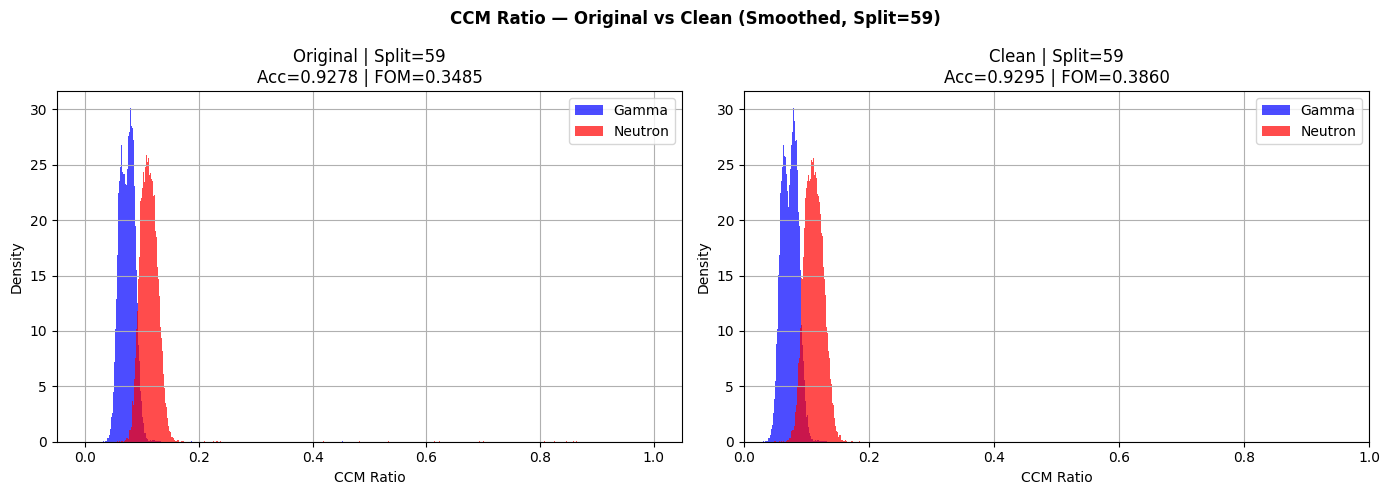

In [22]:
# ── Final Histogram Comparison: Original vs Clean at split=55 ────────────────

compare_split     = 59
split_local       = compare_split - short_start

# Original smoothed
df_g_orig = df_expanded_gamma.iloc[:, short_start:long_end].copy()
df_n_orig = df_expanded_neutron.iloc[:, short_start:long_end].copy()
g_ratio_orig = compute_ratio_smoothed(df_g_orig, split_local)
n_ratio_orig = compute_ratio_smoothed(df_n_orig, split_local)
fom_orig     = calculate_fom(g_ratio_orig, n_ratio_orig)
acc_orig, _, _, _ = get_accuracy_and_roc(g_ratio_orig, n_ratio_orig)

# Clean smoothed
df_g_clean = df_clean_gamma.iloc[:, short_start:long_end].copy()
df_n_clean = df_clean_neutron.iloc[:, short_start:long_end].copy()
g_ratio_clean = compute_ratio_smoothed(df_g_clean, split_local)
n_ratio_clean = compute_ratio_smoothed(df_n_clean, split_local)
fom_clean     = calculate_fom(g_ratio_clean, n_ratio_clean)
acc_clean, _, _, _ = get_accuracy_and_roc(g_ratio_clean, n_ratio_clean)

# ── Plot ──────────────────────────────────────────────────────────────────────
bin_width=0.001
bins_common = np.arange(0, 1 + bin_width, bin_width)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
print(float(len(g_ratio_orig)+len(n_ratio_orig)))
axes[0].hist(g_ratio_orig, bins=bins_common, alpha=0.7, color='blue', label='Gamma', density=True)
axes[0].hist(n_ratio_orig, bins=bins_common, alpha=0.7, color='red',  label='Neutron', density=True)
axes[0].set_xlabel("CCM Ratio")
axes[0].set_ylabel("Density")
axes[0].set_title(f"Original | Split={compare_split}\n"
                  f"Acc={acc_orig:.4f} | FOM={fom_orig:.4f}")
axes[0].legend()
axes[0].grid(True)
for spine in axes[0].spines.values():
    spine.set_visible(True)
print(float(len(g_ratio_clean)+len(n_ratio_clean)))
axes[1].hist(g_ratio_clean, bins=bins_common, alpha=0.7, color='blue', label='Gamma', density=True)
axes[1].hist(n_ratio_clean, bins=bins_common, alpha=0.7, color='red',  label='Neutron', density=True)
axes[1].set_xlim(0,1)
axes[1].set_xlabel("CCM Ratio")
axes[1].set_ylabel("Density")
axes[1].set_title(f"Clean | Split={compare_split}\n"
                  f"Acc={acc_clean:.4f} | FOM={fom_clean:.4f}")
axes[1].legend()
axes[1].grid(True)
for spine in axes[1].spines.values():
    spine.set_visible(True)

plt.suptitle(f"CCM Ratio — Original vs Clean (Smoothed, Split={compare_split})",
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

Charge Weighted comparison Method

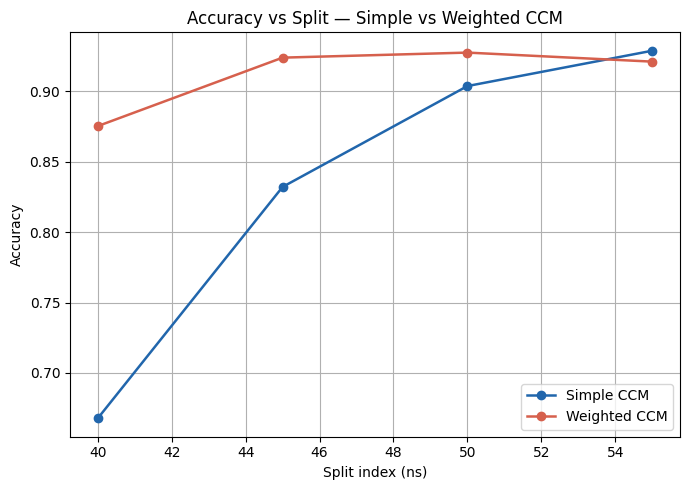

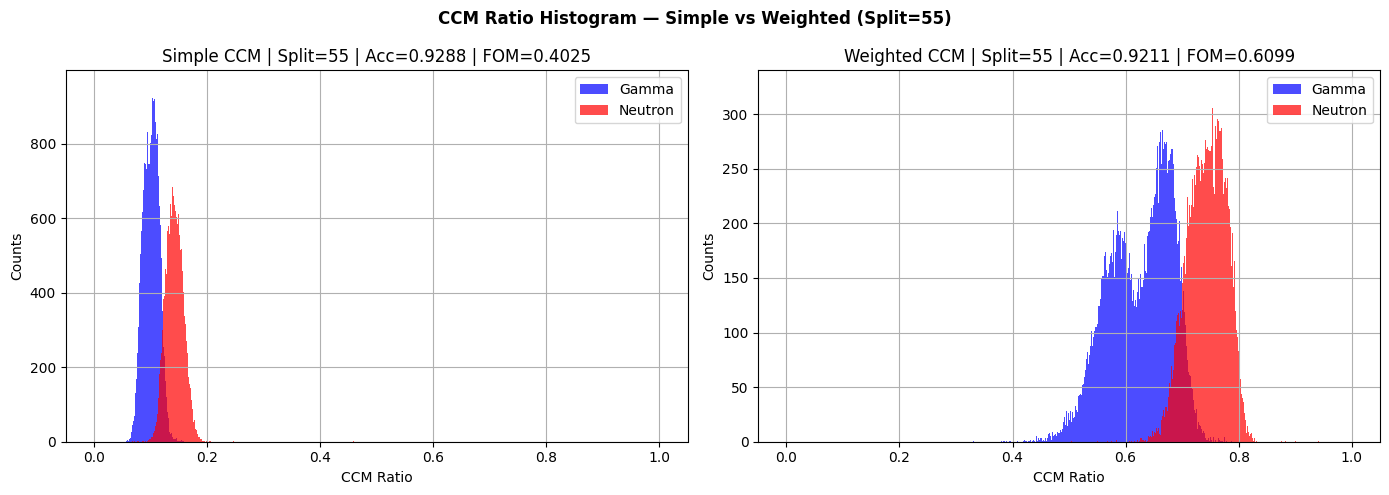

In [70]:
short_start = 25
long_end    = 105
splits      = list(range(40, 56, 5))
bin_width   = 0.001
bins_common = np.arange(0, 1 + bin_width, bin_width)

df_gamma   = df_clean_gamma.iloc[:, short_start:long_end].copy()
df_neutron = df_clean_neutron.iloc[:, short_start:long_end].copy()

def compute_ratio_smoothed(df, split_local, window=5):
    df_s  = moving_average(df, window)
    short = df_s.iloc[:, :split_local].sum(axis=1)
    long_ = df_s.iloc[:, split_local:].sum(axis=1)
    return (long_ / (long_ + short)).abs()
def compute_max(df,window=5):
    df_s    = moving_average(df, window)
    return df_s.max(axis=1)
def compute_charge(df,window=5):
    df_s    = moving_average(df, window)
    return df_s.sum(axis=1)
def compute_tail_curvature(df, window=5):
    df_s   = moving_average(df, window)
    curves = []
    for idx in range(len(df_s)):
        waveform  = df_s.iloc[idx, :].values.astype(float)
        peak_idx  = np.argmax(waveform)
        tail      = waveform[peak_idx:peak_idx+30]  # first 30 samples of tail
        # Fit a line to log(tail) — deviation from linearity = curvature
        log_tail  = np.log(np.clip(tail, 1e-10, None))
        x         = np.arange(len(log_tail))
        coeffs    = np.polyfit(x, log_tail, 2)  # quadratic fit
        curves.append(coeffs[0])                 # quadratic coefficient = curvature
    return pd.Series(curves)
def compute_ratio_smoothed_weighted(df, split_local, window=5):
    df_s      = moving_average(df, window)
    short     = df_s.iloc[:, :split_local].sum(axis=1)
    long_gate = df_s.iloc[:, split_local:]
    weights   = np.arange(1, long_gate.shape[1] + 1)
    long_w    = long_gate.multiply(weights, axis=1).sum(axis=1)
    return (long_w / (long_w + short)).abs()

results = {'Simple CCM':   {'acc': [], 'g_ratio': [], 'n_ratio': []},
           'Weighted CCM': {'acc': [], 'g_ratio': [], 'n_ratio': []}}

for split in splits:
    split_local = split - short_start
    g_simple   = compute_ratio_smoothed(df_gamma,   split_local)
    n_simple   = compute_ratio_smoothed(df_neutron, split_local)
    g_max = compute_max(df_gamma)
    n_max = compute_max(df_neutron)
    g_charge = compute_charge(df_gamma)
    n_charge = compute_charge(df_neutron)
    g_curvature = compute_tail_curvature(df_gamma)
    n_curvature = compute_tail_curvature(df_neutron)
    g_weighted = compute_ratio_smoothed_weighted(df_gamma,   split_local)
    n_weighted = compute_ratio_smoothed_weighted(df_neutron, split_local)
    results['Simple CCM']['acc'].append(get_accuracy_and_roc(g_simple,   n_simple)[0])
    results['Simple CCM']['g_ratio'].append(g_simple)
    results['Simple CCM']['n_ratio'].append(n_simple)
    results['Weighted CCM']['acc'].append(get_accuracy_and_roc(g_weighted, n_weighted)[0])
    results['Weighted CCM']['g_ratio'].append(g_weighted)
    results['Weighted CCM']['n_ratio'].append(n_weighted)

# ── Plot 1: Accuracy vs Split ─────────────────────────────────────────────────

plt.figure(figsize=(7, 5))
plt.plot(splits, results['Simple CCM']['acc'],   marker='o', linewidth=1.8, color='#2166AC', label='Simple CCM')
plt.plot(splits, results['Weighted CCM']['acc'], marker='o', linewidth=1.8, color='#D6604D', label='Weighted CCM')
plt.xlabel("Split index (ns)")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Split — Simple vs Weighted CCM")
plt.legend()
plt.grid(True)
for spine in plt.gca().spines.values():
    spine.set_visible(True)
plt.tight_layout()
plt.show()

# ── Plot 2: Histogram at split=55 ────────────────────────────────────────────

si = splits.index(55)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, method in zip(axes, ['Simple CCM', 'Weighted CCM']):
    g, n  = results[method]['g_ratio'][si], results[method]['n_ratio'][si]
    ax.hist(g, bins=bins_common, alpha=0.7, color='blue', label='Gamma')
    ax.hist(n, bins=bins_common, alpha=0.7, color='red',  label='Neutron')
    ax.set_xlabel("CCM Ratio")
    ax.set_ylabel("Counts")
    ax.set_title(f"{method} | Split=55 | Acc={results[method]['acc'][si]:.4f} | FOM={calculate_fom(g, n):.4f}")
    ax.legend()
    ax.grid(True)
    for spine in ax.spines.values():
        spine.set_visible(True)
plt.suptitle("CCM Ratio Histogram — Simple vs Weighted (Split=55)", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

Time domain

Gamma   slope — mean: -19.9476 | std: 5.5263
Neutron slope — mean: -15.6562 | std: 5.1836

Accuracy: 0.6774 | FOM: 2.9340


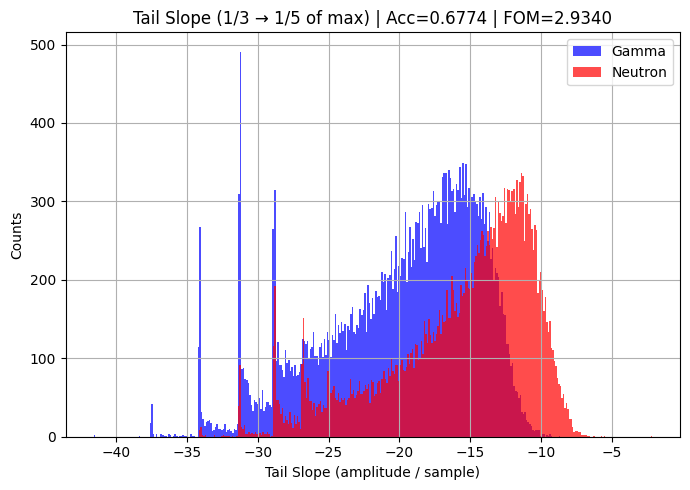

In [42]:
def compute_tail_slope(df, f1=1/2, f2=1/10, window=5):
    """
    For each pulse, computes the slope of the line joining:
    - index where pulse first drops to f1 * max AFTER peak
    - index where pulse first drops to f2 * max AFTER peak
    Slope = (f2*max - f1*max) / (idx_f2 - idx_f1)
    """
    df_s   = moving_average(df, window)
    slopes = []

    for idx in range(len(df_s)):
        waveform  = df_s.iloc[idx, :].values.astype(float)
        max_amp   = waveform.max()
        peak_idx  = np.argmax(waveform)
        post_peak = waveform[peak_idx:]

        # First index after peak where pulse drops to f1 * max
        below_f1 = np.where(post_peak < f1 * max_amp)[0]
        # First index after peak where pulse drops to f2 * max
        below_f2 = np.where(post_peak < f2 * max_amp)[0]

        if len(below_f1) == 0 or len(below_f2) == 0:
            slopes.append(np.nan)
            continue

        idx_f1 = below_f1[0]   # locked in at first crossing
        idx_f2 = below_f2[0]   # locked in at first crossing

        if idx_f2 == idx_f1:   # avoid division by zero
            slopes.append(np.nan)
            continue

        slope = (f2 * max_amp - f1 * max_amp) / (idx_f2 - idx_f1)
        slopes.append(slope)

    return pd.Series(slopes)


# ── Compute slopes ────────────────────────────────────────────────────────────

g_slope = compute_tail_slope(df_clean_gamma.iloc[:, short_start:long_end])
n_slope = compute_tail_slope(df_clean_neutron.iloc[:, short_start:long_end])

# Drop NaNs
g_slope = g_slope.dropna()
n_slope = n_slope.dropna()

print(f"Gamma   slope — mean: {g_slope.mean():.4f} | std: {g_slope.std():.4f}")
print(f"Neutron slope — mean: {n_slope.mean():.4f} | std: {n_slope.std():.4f}")

acc = get_accuracy(g_slope, n_slope)
fom = calculate_fom(g_slope, n_slope, bins=200)
print(f"\nAccuracy: {acc:.4f} | FOM: {fom:.4f}")

# ── Histogram ─────────────────────────────────────────────────────────────────

plt.figure(figsize=(7, 5))
plt.hist(g_slope, bins=300, alpha=0.7, color='blue', label='Gamma')
plt.hist(n_slope, bins=300, alpha=0.7, color='red',  label='Neutron')
plt.xlabel("Tail Slope (amplitude / sample)")
plt.ylabel("Counts")
plt.title(f"Tail Slope (1/3 → 1/5 of max) | Acc={acc:.4f} | FOM={fom:.4f}")
plt.legend()
plt.grid(True)
for spine in plt.gca().spines.values():
    spine.set_visible(True)
plt.tight_layout()
plt.show()

Non-Gaussian Fluctuation Parameter

Gamma   kappa — mean: 148448.6168 | std: 77348.5741
Neutron kappa — mean: 115204.4736 | std: 72291.1842

Accuracy: 0.6305 | FOM: 0.2131


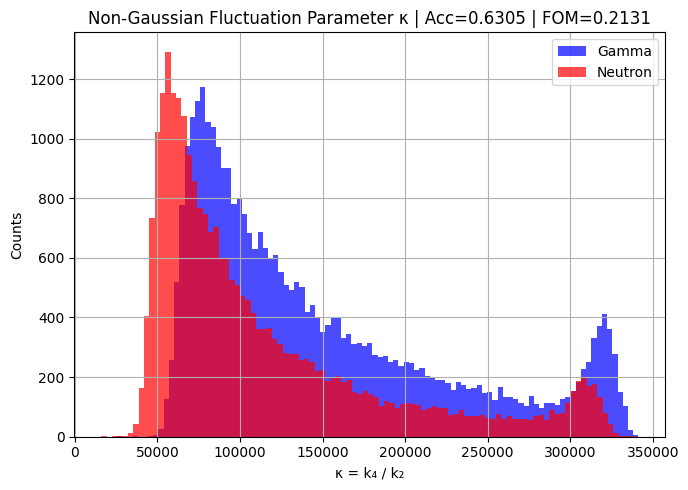

In [43]:
def compute_kappa(df, window=5):
    """
    Computes non-Gaussian fluctuation parameter kappa = k4 / k2
    where k2, k4 are the 2nd and 4th cumulants of the pulse amplitude distribution.
    """
    df_s    = moving_average(df, window)
    t_cols  = df_s.columns
    N       = len(t_cols)

    delta   = df_s.sub(df_s.mean(axis=1), axis=0)

    k2      = (delta ** 2).sum(axis=1) / N
    k4      = (delta ** 4).sum(axis=1) / N
    kappa   = k4 / k2

    return kappa.replace([np.inf, -np.inf], np.nan).dropna()


# ── Compute kappa ─────────────────────────────────────────────────────────────

g_kappa = compute_kappa(df_clean_gamma.iloc[:, short_start:long_end])
n_kappa = compute_kappa(df_clean_neutron.iloc[:, short_start:long_end])

print(f"Gamma   kappa — mean: {g_kappa.mean():.4f} | std: {g_kappa.std():.4f}")
print(f"Neutron kappa — mean: {n_kappa.mean():.4f} | std: {n_kappa.std():.4f}")

acc = get_accuracy(g_kappa, n_kappa)
fom = calculate_fom(g_kappa, n_kappa, bins=200)
print(f"\nAccuracy: {acc:.4f} | FOM: {fom:.4f}")

# ── Histogram ─────────────────────────────────────────────────────────────────

plt.figure(figsize=(7, 5))
plt.hist(g_kappa, bins=100, alpha=0.7, color='blue', label='Gamma')
plt.hist(n_kappa, bins=100, alpha=0.7, color='red',  label='Neutron')
plt.xlabel("κ = k₄ / k₂")
plt.ylabel("Counts")
plt.title(f"Non-Gaussian Fluctuation Parameter κ | Acc={acc:.4f} | FOM={fom:.4f}")
plt.legend()
plt.grid(True)
for spine in plt.gca().spines.values():
    spine.set_visible(True)
plt.tight_layout()
plt.show()


Deep Neural Network


Using device: cpu
Epoch 001/100 | Train Loss: 0.2137 | Val Loss: 0.0580 | Test Acc: 0.9806
Epoch 002/100 | Train Loss: 0.0613 | Val Loss: 0.1302 | Test Acc: 0.9577
Epoch 003/100 | Train Loss: 0.0516 | Val Loss: 0.0520 | Test Acc: 0.9881
Epoch 004/100 | Train Loss: 0.0490 | Val Loss: 0.0671 | Test Acc: 0.9799
Epoch 005/100 | Train Loss: 0.0475 | Val Loss: 0.0456 | Test Acc: 0.9879
Epoch 006/100 | Train Loss: 0.0460 | Val Loss: 0.0447 | Test Acc: 0.9896
Epoch 007/100 | Train Loss: 0.0454 | Val Loss: 0.0325 | Test Acc: 0.9892
Epoch 008/100 | Train Loss: 0.0450 | Val Loss: 0.1586 | Test Acc: 0.9394
Epoch 009/100 | Train Loss: 0.0444 | Val Loss: 0.0291 | Test Acc: 0.9891
Epoch 010/100 | Train Loss: 0.0428 | Val Loss: 0.0489 | Test Acc: 0.9892
Epoch 011/100 | Train Loss: 0.0432 | Val Loss: 0.0425 | Test Acc: 0.9861
Epoch 012/100 | Train Loss: 0.0422 | Val Loss: 0.0449 | Test Acc: 0.9890
Epoch 013/100 | Train Loss: 0.0425 | Val Loss: 0.0454 | Test Acc: 0.9857
Epoch 014/100 | Train Loss: 0.041

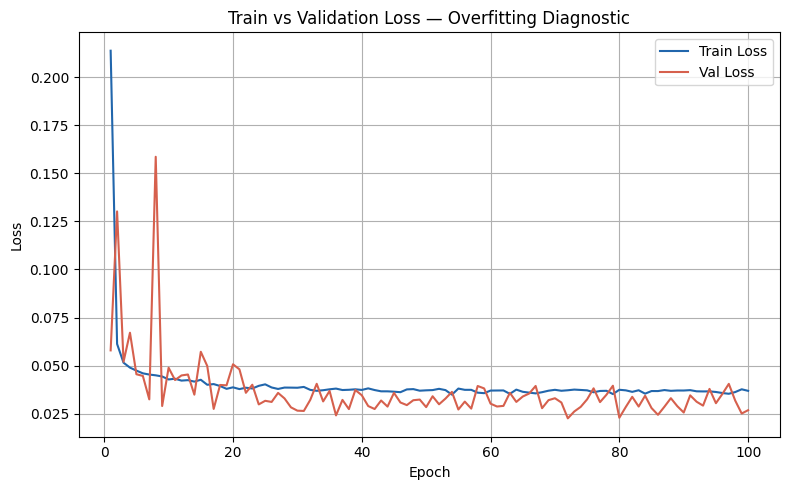

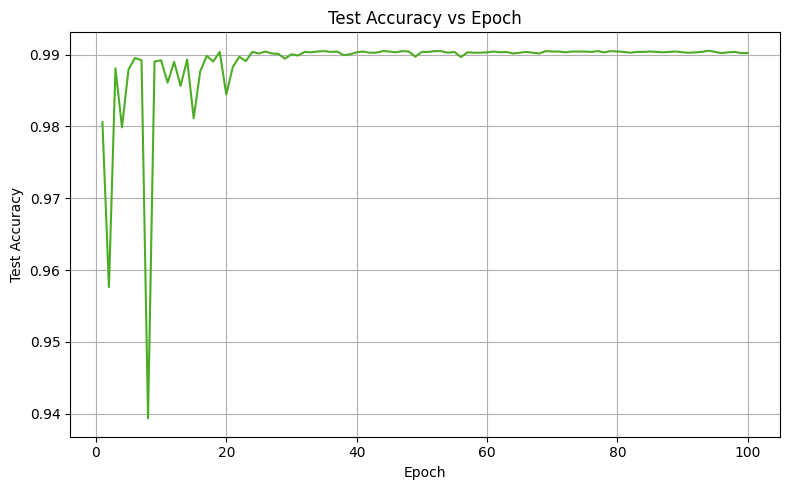

In [75]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, SubsetRandomSampler

# ── Prepare data ──────────────────────────────────────────────────────────────

window = 5
df_g = moving_average(df_clean_gamma.iloc[:,   short_start:long_end], window=window)
df_n = moving_average(df_clean_neutron.iloc[:, short_start:long_end], window=window)

X = np.concatenate([df_g.values, df_n.values], axis=0).astype(np.float32)
y = np.concatenate([np.zeros(len(df_g)), np.ones(len(df_n))]).astype(np.float32)
X = X / (X.max(axis=1, keepdims=True) + 1e-10)

# ── Split: 70% train+val, 30% test ───────────────────────────────────────────

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)

# ── Further split train+val: 90% train, 10% val (per epoch) ──────────────────
# This is done dynamically each epoch via SubsetRandomSampler

n_trainval  = len(X_trainval)
indices     = np.arange(n_trainval)
n_val       = int(0.10 * n_trainval)

trainval_ds = TensorDataset(torch.tensor(X_trainval), torch.tensor(y_trainval))
test_ds     = TensorDataset(torch.tensor(X_test),     torch.tensor(y_test))
test_dl     = DataLoader(test_ds, batch_size=256, shuffle=False)

# ── DNN ───────────────────────────────────────────────────────────────────────

class PulseClassifier(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256), nn.ReLU(), nn.BatchNorm1d(256), nn.Dropout(0.3),
            nn.Linear(256, 128),       nn.ReLU(), nn.BatchNorm1d(128), nn.Dropout(0.3),
            nn.Linear(128, 64),        nn.ReLU(),
            nn.Linear(64, 1),          nn.Sigmoid()
        )
    def forward(self, x):
        return self.net(x).squeeze()

device    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

model     = PulseClassifier(input_dim=X_trainval.shape[1]).to(device)
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=3e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

# ── Training ──────────────────────────────────────────────────────────────────

epochs      = 100
train_losses, val_losses, val_accs = [], [], []

for epoch in range(epochs):

    # Fresh random 90/10 split of trainval every epoch
    np.random.shuffle(indices)
    train_idx = indices[n_val:]
    val_idx   = indices[:n_val]

    train_dl = DataLoader(trainval_ds, batch_size=256,
                          sampler=SubsetRandomSampler(train_idx))
    val_dl   = DataLoader(trainval_ds, batch_size=256,
                          sampler=SubsetRandomSampler(val_idx))

    # ── Train ─────────────────────────────────────────────────────────────────
    model.train()
    epoch_train_loss = 0
    for xb, yb in train_dl:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()
        epoch_train_loss += loss.item()
    epoch_train_loss /= len(train_dl)

    # ── Validate ──────────────────────────────────────────────────────────────
    model.eval()
    epoch_val_loss = 0
    with torch.no_grad():
        for xb, yb in val_dl:
            xb, yb = xb.to(device), yb.to(device)
            loss = criterion(model(xb), yb)
            epoch_val_loss += loss.item()
    epoch_val_loss /= len(val_dl)

    # ── Test accuracy ─────────────────────────────────────────────────────────
    all_preds, all_probs, all_labels = [], [], []
    with torch.no_grad():
        for xb, yb in test_dl:
            probs = model(xb.to(device)).cpu().numpy()
            all_probs.extend(probs)
            all_preds.extend((probs > 0.5).astype(float))
            all_labels.extend(yb.numpy())

    acc = accuracy_score(all_labels, all_preds)
    scheduler.step(epoch_val_loss)
    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)
    val_accs.append(acc)

    print(f"Epoch {epoch+1:03d}/{epochs} | "
          f"Train Loss: {epoch_train_loss:.4f} | "
          f"Val Loss: {epoch_val_loss:.4f} | "
          f"Test Acc: {acc:.4f}")

# ── Final metrics ─────────────────────────────────────────────────────────────

all_probs  = np.array(all_probs)
all_labels = np.array(all_labels)
auc        = roc_auc_score(all_labels, all_probs)
fpr, tpr, _ = roc_curve(all_labels, all_probs)
print(f"\nFinal Test Accuracy: {val_accs[-1]:.4f} | AUC: {auc:.4f}")

# ── Plot 1: Train vs Val Loss ─────────────────────────────────────────────────

plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs+1), train_losses, color='#2166AC', linewidth=1.5, label='Train Loss')
plt.plot(range(1, epochs+1), val_losses,   color='#D6604D', linewidth=1.5, label='Val Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train vs Validation Loss — Overfitting Diagnostic")
plt.legend()
plt.grid(True)
for spine in plt.gca().spines.values():
    spine.set_visible(True)
plt.tight_layout()
plt.show()

# ── Plot 2: Test Accuracy ─────────────────────────────────────────────────────

plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs+1), val_accs, color='#4DAC26', linewidth=1.5)
plt.xlabel("Epoch")
plt.ylabel("Test Accuracy")
plt.title("Test Accuracy vs Epoch")
plt.grid(True)
for spine in plt.gca().spines.values():
    spine.set_visible(True)
plt.tight_layout()
plt.show()


Train size=10% | Acc=0.6845
Train size=20% | Acc=0.9738
Train size=40% | Acc=0.8891
Train size=60% | Acc=0.9868
Train size=80% | Acc=0.9743


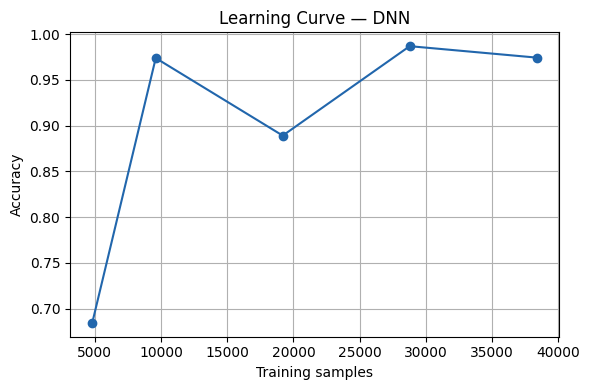

Shuffled label accuracy (should be ~0.50): 0.5588


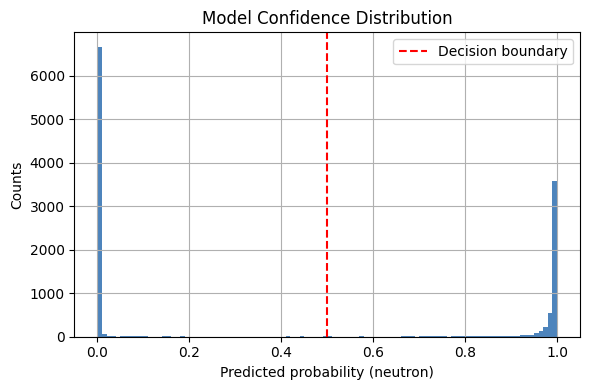

Misclassified: 244 / 11995


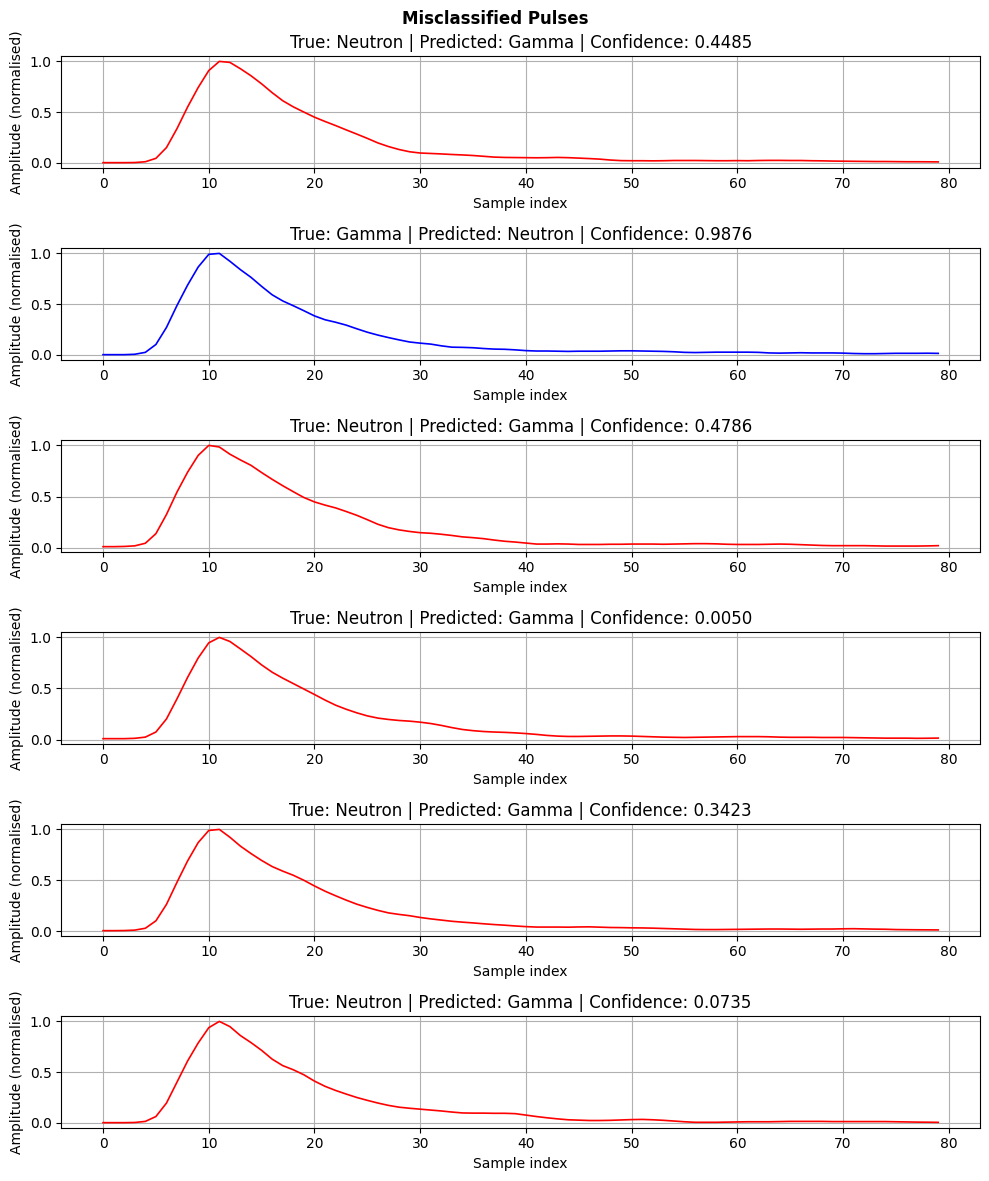

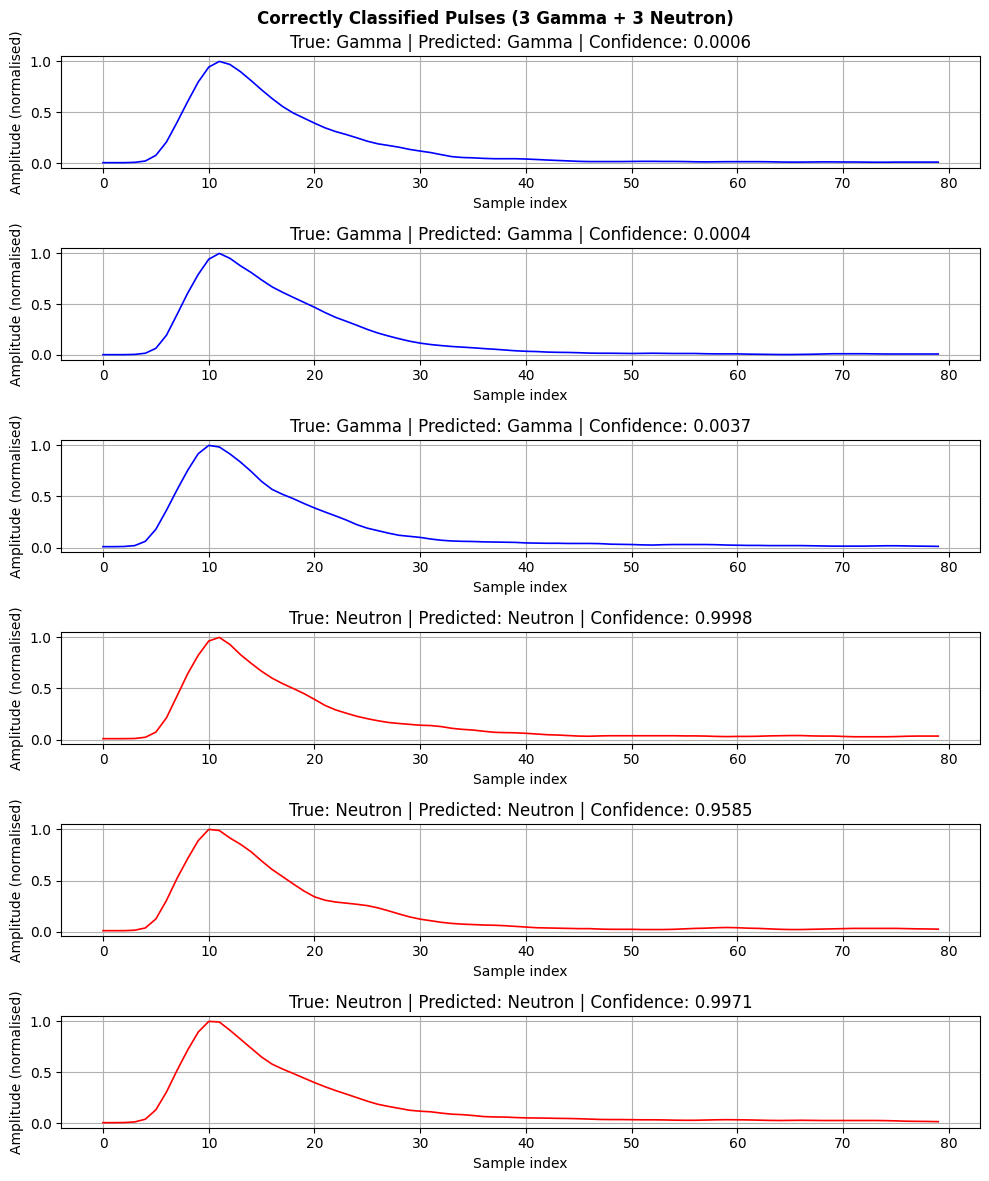

In [56]:
# ── Test 1: Learning curve ────────────────────────────────────────────────────

train_sizes = [0.1, 0.2, 0.4, 0.6, 0.8]
size_accs   = []

for size in train_sizes:
    X_tr, _, y_tr, _ = train_test_split(X_train, y_train,
                                         train_size=size,
                                         stratify=y_train,
                                         random_state=42)
    tr_ds = DataLoader(TensorDataset(torch.tensor(X_tr),
                                      torch.tensor(y_tr)),
                       batch_size=256, shuffle=True)
    m   = PulseClassifier(input_dim=X_train.shape[1]).to(device)
    opt = torch.optim.Adam(m.parameters(), lr=1e-3)
    m.train()
    for _ in range(10):
        for xb, yb in tr_ds:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            nn.BCELoss()(m(xb), yb).backward()
            opt.step()
    m.eval()
    preds = []
    with torch.no_grad():
        for xb, yb in test_dl:
            preds.extend((m(xb.to(device)).cpu().numpy() > 0.5).astype(float))
    size_accs.append(accuracy_score(all_labels, preds))
    print(f"Train size={size:.0%} | Acc={size_accs[-1]:.4f}")

plt.figure(figsize=(6, 4))
plt.plot([s * len(X_train) for s in train_sizes], size_accs, marker='o', color='#2166AC')
plt.xlabel("Training samples")
plt.ylabel("Accuracy")
plt.title("Learning Curve — DNN")
plt.grid(True)
for spine in plt.gca().spines.values():
    spine.set_visible(True)
plt.tight_layout()
plt.show()

# ── Test 2: Shuffle labels ────────────────────────────────────────────────────

y_shuffled = y_train.copy()
np.random.shuffle(y_shuffled)
shuf_ds = DataLoader(TensorDataset(torch.tensor(X_train),
                                    torch.tensor(y_shuffled)),
                     batch_size=256, shuffle=True)
m_shuf = PulseClassifier(input_dim=X_train.shape[1]).to(device)
opt    = torch.optim.Adam(m_shuf.parameters(), lr=1e-3)
m_shuf.train()
for _ in range(10):
    for xb, yb in shuf_ds:
        xb, yb = xb.to(device), yb.to(device)
        opt.zero_grad()
        nn.BCELoss()(m_shuf(xb), yb).backward()
        opt.step()
m_shuf.eval()
shuf_preds = []
with torch.no_grad():
    for xb, yb in test_dl:
        shuf_preds.extend((m_shuf(xb.to(device)).cpu().numpy() > 0.5).astype(float))
print(f"Shuffled label accuracy (should be ~0.50): {accuracy_score(all_labels, shuf_preds):.4f}")

# ── Test 3: Confidence distribution ──────────────────────────────────────────

model.eval()
all_probs_test = []
with torch.no_grad():
    for xb, yb in test_dl:
        all_probs_test.extend(model(xb.to(device)).cpu().numpy())
all_probs_test = np.array(all_probs_test)

plt.figure(figsize=(6, 4))
plt.hist(all_probs_test, bins=100, color='#2166AC', alpha=0.8)
plt.axvline(0.5, color='red', linestyle='--', label='Decision boundary')
plt.xlabel("Predicted probability (neutron)")
plt.ylabel("Counts")
plt.title("Model Confidence Distribution")
plt.legend()
plt.grid(True)
for spine in plt.gca().spines.values():
    spine.set_visible(True)
plt.tight_layout()
plt.show()

# ── Test 4: Misclassified pulses ──────────────────────────────────────────────

misclassified = np.where(np.array(all_preds) != all_labels)[0]
print(f"Misclassified: {len(misclassified)} / {len(all_labels)}")

if len(misclassified) > 0:
    fig, axes = plt.subplots(min(6, len(misclassified)), 1, figsize=(10, 12))
    if len(misclassified) == 1:
        axes = [axes]
    for i, idx in enumerate(misclassified[:6]):
        true_label = 'Neutron' if all_labels[idx] == 1 else 'Gamma'
        pred_label = 'Neutron' if all_preds[idx]  == 1 else 'Gamma'
        color      = 'red'  if true_label == 'Neutron' else 'blue'
        axes[i].plot(X_test[idx], color=color, linewidth=1.2)
        axes[i].set_title(f"True: {true_label} | Predicted: {pred_label} | "
                          f"Confidence: {all_probs_test[idx]:.4f}")
        axes[i].set_xlabel("Sample index")
        axes[i].set_ylabel("Amplitude (normalised)")
        axes[i].grid(True)
        for spine in axes[i].spines.values():
            spine.set_visible(True)
    plt.suptitle("Misclassified Pulses", fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

# ── Test 5: Correctly classified pulses ──────────────────────────────────────

correctly_classified = np.where(np.array(all_preds) == all_labels)[0]
correct_gamma   = [i for i in correctly_classified if all_labels[i] == 0]
correct_neutron = [i for i in correctly_classified if all_labels[i] == 1]
sample_correct  = (np.random.choice(correct_gamma,   3, replace=False).tolist() +
                   np.random.choice(correct_neutron, 3, replace=False).tolist())

fig, axes = plt.subplots(6, 1, figsize=(10, 12))
for i, idx in enumerate(sample_correct):
    true_label = 'Neutron' if all_labels[idx] == 1 else 'Gamma'
    color      = 'red' if true_label == 'Neutron' else 'blue'
    axes[i].plot(X_test[idx], color=color, linewidth=1.2)
    axes[i].set_title(f"True: {true_label} | Predicted: {true_label} | "
                      f"Confidence: {all_probs_test[idx]:.4f}")
    axes[i].set_xlabel("Sample index")
    axes[i].set_ylabel("Amplitude (normalised)")
    axes[i].grid(True)
    for spine in axes[i].spines.values():
        spine.set_visible(True)
plt.suptitle("Correctly Classified Pulses (3 Gamma + 3 Neutron)",
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

1D CNN


── Training DNN ─────────────────────────────────────────────────────────
  Epoch 01/50 | Loss: 0.1720 | Acc: 0.8547
  Epoch 02/50 | Loss: 0.0539 | Acc: 0.9806
  Epoch 03/50 | Loss: 0.0494 | Acc: 0.9826
  Epoch 04/50 | Loss: 0.0477 | Acc: 0.9890
  Epoch 05/50 | Loss: 0.0467 | Acc: 0.8632
  Epoch 06/50 | Loss: 0.0442 | Acc: 0.9705
  Epoch 07/50 | Loss: 0.0435 | Acc: 0.9366
  Epoch 08/50 | Loss: 0.0433 | Acc: 0.9805
  Epoch 09/50 | Loss: 0.0424 | Acc: 0.9787
  Epoch 10/50 | Loss: 0.0409 | Acc: 0.9823
  Epoch 11/50 | Loss: 0.0404 | Acc: 0.9902
  Epoch 12/50 | Loss: 0.0398 | Acc: 0.9796
  Epoch 13/50 | Loss: 0.0406 | Acc: 0.9832
  Epoch 14/50 | Loss: 0.0407 | Acc: 0.9907
  Epoch 15/50 | Loss: 0.0400 | Acc: 0.9823
  Epoch 16/50 | Loss: 0.0397 | Acc: 0.9842
  Epoch 17/50 | Loss: 0.0403 | Acc: 0.9897
  Epoch 18/50 | Loss: 0.0387 | Acc: 0.9827
  Epoch 19/50 | Loss: 0.0395 | Acc: 0.9791
  Epoch 20/50 | Loss: 0.0393 | Acc: 0.9879
  Epoch 21/50 | Loss: 0.0398 | Acc: 0.9875
  Epoch 22/50 | Loss: 0

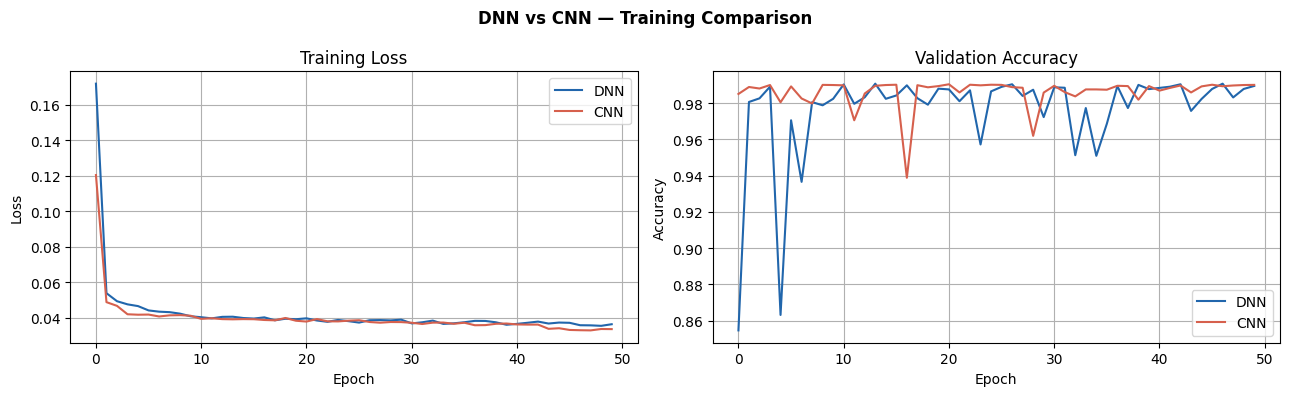

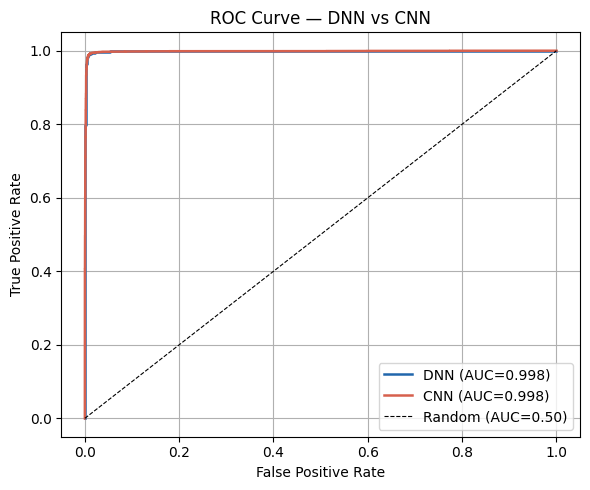

In [57]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# ── Prepare data ──────────────────────────────────────────────────────────────

window = 5
df_g = moving_average(df_clean_gamma.iloc[:,   short_start:long_end], window=window)
df_n = moving_average(df_clean_neutron.iloc[:, short_start:long_end], window=window)

X = np.concatenate([df_g.values, df_n.values], axis=0).astype(np.float32)
y = np.concatenate([np.zeros(len(df_g)), np.ones(len(df_n))]).astype(np.float32)
X = X / (X.max(axis=1, keepdims=True) + 1e-10)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# DNN datasets — shape (N, 80)
train_dl_dnn = DataLoader(TensorDataset(torch.tensor(X_train), torch.tensor(y_train)),
                           batch_size=256, shuffle=True)
test_dl_dnn  = DataLoader(TensorDataset(torch.tensor(X_test),  torch.tensor(y_test)),
                           batch_size=256, shuffle=False)

# CNN datasets — shape (N, 1, 80) — extra channel dimension
train_dl_cnn = DataLoader(TensorDataset(torch.tensor(X_train[:, None, :]), torch.tensor(y_train)),
                           batch_size=256, shuffle=True)
test_dl_cnn  = DataLoader(TensorDataset(torch.tensor(X_test[:, None, :]),  torch.tensor(y_test)),
                           batch_size=256, shuffle=False)

# ── DNN ───────────────────────────────────────────────────────────────────────

class PulseClassifierDNN(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256), nn.ReLU(), nn.BatchNorm1d(256), nn.Dropout(0.3),
            nn.Linear(256, 128),       nn.ReLU(), nn.BatchNorm1d(128), nn.Dropout(0.3),
            nn.Linear(128, 64),        nn.ReLU(),
            nn.Linear(64, 1),          nn.Sigmoid()
        )
    def forward(self, x):
        return self.net(x).squeeze()

# ── 1D CNN ────────────────────────────────────────────────────────────────────

class PulseClassifierCNN(nn.Module):
    def __init__(self, input_len):
        super().__init__()
        self.conv = nn.Sequential(
            # Block 1 — learn local rise/fall patterns
            nn.Conv1d(1, 32, kernel_size=5, padding=2), nn.ReLU(), nn.BatchNorm1d(32),
            nn.MaxPool1d(2),                             # 80 → 40

            # Block 2 — learn mid-range tail features
            nn.Conv1d(32, 64, kernel_size=5, padding=2), nn.ReLU(), nn.BatchNorm1d(64),
            nn.MaxPool1d(2),                              # 40 → 20

            # Block 3 — learn high-level decay shape
            nn.Conv1d(64, 128, kernel_size=3, padding=1), nn.ReLU(), nn.BatchNorm1d(128),
            nn.MaxPool1d(2),                               # 20 → 10
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 10, 64), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, 1),        nn.Sigmoid()
        )
    def forward(self, x):
        return self.fc(self.conv(x)).squeeze()

# ── Training function ─────────────────────────────────────────────────────────

def train_model(model, train_dl, test_dl, epochs=50, lr=3e-4):
    device    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model     = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)
    criterion = nn.BCELoss()

    train_losses, val_accs = [], []
    all_preds = all_probs = all_labels = None

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        for xb, yb in train_dl:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        model.eval()
        preds, probs, labels = [], [], []
        with torch.no_grad():
            for xb, yb in test_dl:
                p = model(xb.to(device)).cpu().numpy()
                probs.extend(p)
                preds.extend((p > 0.5).astype(float))
                labels.extend(yb.numpy())

        acc      = accuracy_score(labels, preds)
        loss_avg = epoch_loss / len(train_dl)
        scheduler.step(loss_avg)
        train_losses.append(loss_avg)
        val_accs.append(acc)
        print(f"  Epoch {epoch+1:02d}/{epochs} | Loss: {loss_avg:.4f} | Acc: {acc:.4f}")

        all_preds, all_probs, all_labels = preds, np.array(probs), np.array(labels)

    auc         = roc_auc_score(all_labels, all_probs)
    fpr, tpr, _ = roc_curve(all_labels, all_probs)
    return train_losses, val_accs, all_preds, all_probs, all_labels, auc, fpr, tpr

# ── Train both ────────────────────────────────────────────────────────────────

device    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
input_len = X_train.shape[1]
epochs    = 50

print("── Training DNN ─────────────────────────────────────────────────────────")
dnn = PulseClassifierDNN(input_dim=input_len)
dnn_loss, dnn_acc, dnn_preds, dnn_probs, dnn_labels, dnn_auc, dnn_fpr, dnn_tpr = \
    train_model(dnn, train_dl_dnn, test_dl_dnn, epochs=epochs)

print("\n── Training CNN ─────────────────────────────────────────────────────────")
cnn = PulseClassifierCNN(input_len=input_len)
cnn_loss, cnn_acc, cnn_preds, cnn_probs, cnn_labels, cnn_auc, cnn_fpr, cnn_tpr = \
    train_model(cnn, train_dl_cnn, test_dl_cnn, epochs=epochs)

print(f"\nDNN — Final Acc: {dnn_acc[-1]:.4f} | AUC: {dnn_auc:.4f}")
print(f"CNN — Final Acc: {cnn_acc[-1]:.4f} | AUC: {cnn_auc:.4f}")

# ── Plot 1: Training curves ───────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(dnn_loss, color='#2166AC', linewidth=1.5, label='DNN')
axes[0].plot(cnn_loss, color='#D6604D', linewidth=1.5, label='CNN')
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Training Loss")
axes[0].legend()
axes[0].grid(True)
for spine in axes[0].spines.values():
    spine.set_visible(True)

axes[1].plot(dnn_acc, color='#2166AC', linewidth=1.5, label='DNN')
axes[1].plot(cnn_acc, color='#D6604D', linewidth=1.5, label='CNN')
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Validation Accuracy")
axes[1].legend()
axes[1].grid(True)
for spine in axes[1].spines.values():
    spine.set_visible(True)

plt.suptitle("DNN vs CNN — Training Comparison", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Plot 2: ROC curves ────────────────────────────────────────────────────────

plt.figure(figsize=(6, 5))
plt.plot(dnn_fpr, dnn_tpr, color='#2166AC', linewidth=1.8, label=f"DNN (AUC={dnn_auc:.3f})")
plt.plot(cnn_fpr, cnn_tpr, color='#D6604D', linewidth=1.8, label=f"CNN (AUC={cnn_auc:.3f})")
plt.plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='Random (AUC=0.50)')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — DNN vs CNN")
plt.legend()
plt.grid(True)
for spine in plt.gca().spines.values():
    spine.set_visible(True)
plt.tight_layout()
plt.show()

In [ ]:
# Combine all your engineered features
features_gamma = np.column_stack([
    g_simple,    # CCM ratio
    g_weighted,  # weighted CCM ratio
    g_slope,           # tail slope
    g_max,         # peak width
    g_charge,
    g_curvature,
    g_kappa            # kappa
])

features_neutron = np.column_stack([
    n_simple,
    n_weighted,
    n_slope,
    n_max,
    n_charge,
    n_curvature,
    n_kappa
])

X = np.concatenate([features_gamma, features_neutron], axis=0)
y = np.concatenate([np.zeros(len(features_gamma)), np.ones(len(features_neutron))])

# Use Random Forest — handles non-linear combinations of features well
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
acc = accuracy_score(y_test, rf.predict(X_test))
print(f"Random Forest (all features) Accuracy: {acc:.4f}")

# Feature importance — tells you which feature matters most
importances = rf.feature_importances_
feature_names = ['CCM Simple', 'CCM Weighted', 'Tail Slope', 'peak amplitude','pulse charge','tail curvature', 'Kappa']
for name, imp in sorted(zip(feature_names, importances), key=lambda x: -x[1]):
    print(f"  {name}: {imp:.4f}")

Random Forest (all features) Accuracy: 0.9465
  CCM Simple: 0.6576
  tail curvature: 0.0964
  Tail Slope: 0.0941
  Kappa: 0.0572
  pulse charge: 0.0550
  peak amplitude: 0.0398
